# Dataset loading

The full training/validation dataset includes 516 melting temperatures of 12 sequences at mixtures of Monovalent (Mainly Tris and Potassium) and Divalent (Mainly Magnesium) ions.\
The testing set includes 39 melting temperature of other sequences.

In [118]:
# Loading the training/validation data and test data
import pandas as pd
import numpy as np
owc2008_table4 = pd.read_csv('datasets/owc2008_table4_all516.csv') # Training and validation data
owc2008_table4.head(10)

,duplex_id,sequence_5to3,length_bp,monovalent_mM,Mg2+_mM,Tm_C
0,ODN1,TTCTACCTATGTGAT,15,1,0.5,43.3
1,ODN1,TTCTACCTATGTGAT,15,1,1.5,46.1
2,ODN1,TTCTACCTATGTGAT,15,1,3.0,47.8
3,ODN1,TTCTACCTATGTGAT,15,1,10.0,50.2
4,ODN1,TTCTACCTATGTGAT,15,1,20.0,50.4
5,ODN1,TTCTACCTATGTGAT,15,5,0.5,42.1
6,ODN1,TTCTACCTATGTGAT,15,5,1.5,45.6
7,ODN1,TTCTACCTATGTGAT,15,5,3.0,47.6
8,ODN1,TTCTACCTATGTGAT,15,5,10.0,49.5
9,ODN1,TTCTACCTATGTGAT,15,5,20.0,50.4


In [119]:
owc2008_tableS2 = pd.read_csv('datasets/owc2008_tableS2_cleaned.csv') # Test data
owc2008_tableS2.drop(owc2008_tableS2.columns[[2,3]], axis=1).head(10)

,sequence_5to3,length_bp,Mg2+_mM,Tm_C
0,CTGACGACAAGACT,14,1.5,51.8
1,CTGACGACAAGACT,14,10.0,56.3
2,GTAACCGGCATGAA,14,20.0,57.0
3,GTAACCGGCATGAA,14,20.0,57.0
4,CGCTGCTCACCTGA,14,3.0,59.6
5,CGCTGCTCACCTGA,14,125.0,62.0
6,TCTCAATGGTGTTACG,16,1.5,51.8
7,TCTCAATGGTGTTACG,16,0.5,49.0
8,TCTCAAACACCACACG,16,3.0,57.7
9,TCTCAAACACCACACG,16,10.0,60.0


In [120]:
# Drop the duplex_id column since it is captured anyway through the sequence column
owc2008_table4.drop(columns=['duplex_id'], inplace=True)

# Add log-salt columns since we know from the literature that the relationship between salt and Tm is logarithmic
# To be used later on
owc2008_table4['log_monovalent_M'] = np.log(owc2008_table4['monovalent_mM']*1e-3 + 1e-6)  # Convert to M and add a small constant to avoid log(0)
owc2008_table4['log_Mg2+_M'] = np.log(owc2008_table4['Mg2+_mM']*1e-3+1e-6)  # Convert to M and add a small constant to avoid log(0)

# Do the same for the test data
owc2008_tableS2['log_monovalent_M'] = np.log(owc2008_tableS2['monovalent_mM']*1e-3 + 1e-6)  # Convert to M and add a small constant to avoid log(0)
owc2008_tableS2['log_Mg2+_M'] = np.log(owc2008_tableS2['Mg2+_mM']*1e-3+1e-6)  # Convert to M and add a small constant to avoid log(0)


owc2008_table4.head(10)

,sequence_5to3,length_bp,monovalent_mM,Mg2+_mM,Tm_C,log_monovalent_M,log_Mg2+_M
0,TTCTACCTATGTGAT,15,1,0.5,43.3,-6.906756,-7.598904
1,TTCTACCTATGTGAT,15,1,1.5,46.1,-6.906756,-6.501624
2,TTCTACCTATGTGAT,15,1,3.0,47.8,-6.906756,-5.808810
3,TTCTACCTATGTGAT,15,1,10.0,50.2,-6.906756,-4.605070
4,TTCTACCTATGTGAT,15,1,20.0,50.4,-6.906756,-3.911973
5,TTCTACCTATGTGAT,15,5,0.5,42.1,-5.298117,-7.598904
6,TTCTACCTATGTGAT,15,5,1.5,45.6,-5.298117,-6.501624
7,TTCTACCTATGTGAT,15,5,3.0,47.6,-5.298117,-5.808810
8,TTCTACCTATGTGAT,15,5,10.0,49.5,-5.298117,-4.605070
9,TTCTACCTATGTGAT,15,5,20.0,50.4,-5.298117,-3.911973


# Models and Metrics

As introduced in the EDA notebook, our goal is two fold
1. We would like to acheieve high predicition accuracy (Low MAE) with a limited number of data points (516 melting temperature - 12 Main sequences).
2. We *hope* to have a simple/interpretable model that captures the most biophysically relevant dependencies of the melting temperature (Low complexity and number of features).

To handle the first point, we will be using **Mean Absolute Error (MAE)** as our metric since it was the main metric used by the prior studies (Owc-2008).\
Also, given the limited number of data points and the target accuracy, I think it will be best to use non-linear models that handle such scenarios right away. **In particular, we will compare LinearRegression (LR), GeneralizedAdditiveModels (GAM), and DecesionTreeRegressor (DT).** \
Given the EDA we did in the EDA notebook, non-linear dependencies and salt interactions seem unavoidable, so these models would be our first approach in capturing such complexity and confirm such behavior.

To investigate the second point, we will test the winning models on multiple variations of the dataset each with **a different set of features (Features Engineering)** to find *the minimal set* of features needed to generalize to unseen data. This will help us narrow down the most important features and potential salt-feature interactions.\
The point of intpretability/simplicity is a challenge, but **LR and GAM** should make it possible to tackle such challenges.\
**DT** would be the next more complex model that captures non-linear effects, but it is also more likely to overfit. We consider it as well for completeness.

# Features engineering

We will test different sets of features to select the most important ones.\
**The best performing model should be the one performing the best in terms of the number of features and the validation-MAE score (Lower=Better, for both).**

As explored in the EDA notebook and as seen in literature, the melting temperature is highly dependent on GC-content, Duplex Length, and Log[Salt], but it will be nice to see how good a model that has other features engineered is doing.\
The main motivation of the features used should be its ability to generalize to unseen sequences (beyond those 12), so we will try to extract important features of those 12 sequences at hand that can capture their primary properties, yet sharable by similar sequences and easier to generalize.\
In particular, the duplex length will need to be present in all sets of features since it is *a signature property*; however, the GC-content for example can be captured in different ways.

To this end, we will compare the models performance on three sets of features:
1. *The typical set of features - our baseline model*: Similar to the ones usually found in literature, we add the GC-content feature. 
2. *The naive set of features*: This will just include the fraction of each nucleotide (A,T,C,G). 
3. *The modern set of features*: This will use the fraction of the ten different dinucleotide steps (AA/TT, GC/CG, AC/GT, ...) to capture the suggestion of the more recent papers (Unzip-2010 and Unzip-2017). For simplicity, we will ignore the two terminal contributions (Edge effects) for now (Unzip-2010).

Generally:
1. They all include the duplex length, as highlighted before.
2. They all include monovalent and divalent salt concentrations in mM.\
We will also check if Log-transformation of the salt concentration in M is necessary, following literature trends.
3. For each set of features, we will have a FeaturexSalt-interaction set.
This will include Monovalent_mMxFeature and Divalent_mMxFeature, for each feature.

## 1.1 Typical set of features

In [121]:
salt_baseline_features = ['monovalent_mM', 'Mg2+_mM']
sequence_baseline_features = ['length_bp', 'GC_content']

typical_features_no_salt_interaction = salt_baseline_features + sequence_baseline_features

# Add length_bp and GC-content columns
owc2008_table4['length_bp'] = owc2008_table4['sequence_5to3'].apply(len)
owc2008_table4['GC_content'] = owc2008_table4['sequence_5to3'].apply(lambda seq: (seq.count('G') + seq.count('C')) / len(seq) if len(seq) > 0 else 0)

# Do the same thing for the test data
owc2008_tableS2['length_bp'] = owc2008_tableS2['sequence_5to3'].apply(len)
owc2008_tableS2['GC_content'] = owc2008_tableS2['sequence_5to3'].apply(lambda seq: (seq.count('G') + seq.count('C')) / len(seq) if len(seq) > 0 else 0)

owc2008_table4[typical_features_no_salt_interaction].head(10)

,monovalent_mM,Mg2+_mM,length_bp,GC_content
0,1,0.5,15,0.333333
1,1,1.5,15,0.333333
2,1,3.0,15,0.333333
3,1,10.0,15,0.333333
4,1,20.0,15,0.333333
5,5,0.5,15,0.333333
6,5,1.5,15,0.333333
7,5,3.0,15,0.333333
8,5,10.0,15,0.333333
9,5,20.0,15,0.333333


## 1.2 Typical set of features (with salt interactions)

In [122]:
typical_features_with_salt_interaction = typical_features_no_salt_interaction.copy() # To avoid modifying the original list

# Add salt interaction features to the DataFrame
for salt in salt_baseline_features:
    for feature in sequence_baseline_features:
        owc2008_table4[f'{salt}-{feature}'] = owc2008_table4[salt] * owc2008_table4[feature]
        # Similarly, we add the interaction features to the test data
        owc2008_tableS2[f'{salt}-{feature}'] = owc2008_tableS2[salt] * owc2008_tableS2[feature]
        typical_features_with_salt_interaction.append(f'{salt}-{feature}')

owc2008_table4[typical_features_with_salt_interaction].head(10)

,monovalent_mM,Mg2+_mM,length_bp,GC_content,monovalent_mM-length_bp,monovalent_mM-GC_content,Mg2+_mM-length_bp,Mg2+_mM-GC_content
0,1,0.5,15,0.333333,15,0.333333,7.5,0.166667
1,1,1.5,15,0.333333,15,0.333333,22.5,0.500000
2,1,3.0,15,0.333333,15,0.333333,45.0,1.000000
3,1,10.0,15,0.333333,15,0.333333,150.0,3.333333
4,1,20.0,15,0.333333,15,0.333333,300.0,6.666667
5,5,0.5,15,0.333333,75,1.666667,7.5,0.166667
6,5,1.5,15,0.333333,75,1.666667,22.5,0.500000
7,5,3.0,15,0.333333,75,1.666667,45.0,1.000000
8,5,10.0,15,0.333333,75,1.666667,150.0,3.333333
9,5,20.0,15,0.333333,75,1.666667,300.0,6.666667


## 2.1 Naive set of features

Given the constraint of *Sum(fractions)=1*, it is redundunt to simultanously have the four fractions, so we only keep three of them here.\
In particular, we drop the fraction of A or T and keep the fractions of G and C since (GC-content=f_C+f_G), so we are adding one new feature on top of the previous ones.

In [123]:
naive_baseline_features = ['f_A', 'f_G', 'f_C', 'length_bp']
naive_features_no_salt_interaction = naive_baseline_features + salt_baseline_features

# Add the counts of each nucleotide as features
for nucleotide in ['A', 'G', 'C']:
    owc2008_table4[f'f_{nucleotide}'] = owc2008_table4['sequence_5to3'].apply(lambda seq: seq.count(nucleotide)/len(seq) if len(seq) > 0 else 0)
    # Do the same thing for the test data
    owc2008_tableS2[f'f_{nucleotide}'] = owc2008_tableS2['sequence_5to3'].apply(lambda seq: seq.count(nucleotide)/len(seq) if len(seq) > 0 else 0)

owc2008_table4[naive_features_no_salt_interaction].head(10)

,f_A,f_G,f_C,length_bp,monovalent_mM,Mg2+_mM
0,0.2,0.133333,0.2,15,1,0.5
1,0.2,0.133333,0.2,15,1,1.5
2,0.2,0.133333,0.2,15,1,3.0
3,0.2,0.133333,0.2,15,1,10.0
4,0.2,0.133333,0.2,15,1,20.0
5,0.2,0.133333,0.2,15,5,0.5
6,0.2,0.133333,0.2,15,5,1.5
7,0.2,0.133333,0.2,15,5,3.0
8,0.2,0.133333,0.2,15,5,10.0
9,0.2,0.133333,0.2,15,5,20.0


## 2.2 Naive set of features (with salt interaction)

In [124]:
naive_features_with_salt_interaction = naive_features_no_salt_interaction.copy() 

for salt in salt_baseline_features:
    for feature in naive_baseline_features:
        owc2008_table4[f'{salt}-{feature}'] = owc2008_table4[salt] * owc2008_table4[f'{feature}']
        naive_features_with_salt_interaction.append(f'{salt}-{feature}')
        # Do the same thing for the test data
        owc2008_tableS2[f'{salt}-{feature}'] = owc2008_tableS2[salt] * owc2008_tableS2[f'{feature}']


owc2008_table4[naive_features_with_salt_interaction].head(10)

,f_A,f_G,f_C,length_bp,monovalent_mM,Mg2+_mM,monovalent_mM-f_A,monovalent_mM-f_G,monovalent_mM-f_C,monovalent_mM-length_bp,Mg2+_mM-f_A,Mg2+_mM-f_G,Mg2+_mM-f_C,Mg2+_mM-length_bp
0,0.2,0.133333,0.2,15,1,0.5,0.2,0.133333,0.2,15,0.1,0.066667,0.1,7.5
1,0.2,0.133333,0.2,15,1,1.5,0.2,0.133333,0.2,15,0.3,0.200000,0.3,22.5
2,0.2,0.133333,0.2,15,1,3.0,0.2,0.133333,0.2,15,0.6,0.400000,0.6,45.0
3,0.2,0.133333,0.2,15,1,10.0,0.2,0.133333,0.2,15,2.0,1.333333,2.0,150.0
4,0.2,0.133333,0.2,15,1,20.0,0.2,0.133333,0.2,15,4.0,2.666667,4.0,300.0
5,0.2,0.133333,0.2,15,5,0.5,1.0,0.666667,1.0,75,0.1,0.066667,0.1,7.5
6,0.2,0.133333,0.2,15,5,1.5,1.0,0.666667,1.0,75,0.3,0.200000,0.3,22.5
7,0.2,0.133333,0.2,15,5,3.0,1.0,0.666667,1.0,75,0.6,0.400000,0.6,45.0
8,0.2,0.133333,0.2,15,5,10.0,1.0,0.666667,1.0,75,2.0,1.333333,2.0,150.0
9,0.2,0.133333,0.2,15,5,20.0,1.0,0.666667,1.0,75,4.0,2.666667,4.0,300.0


## 3.1 Modern set of features

Out of the ten dinucleotide steps, eight are independent (SantaLucia-1998, Unzip-2017, and Volo-2018). Hence, we drop the extra two dinucleotide steps (GC/CG and TA/AT) to avoid colinearity.

In [125]:
# The ten dinucleotide with 2 terminal factors ('AA/TT', 'AT/TA', 'TA/AT', 'CA/GT', 'GT/CA', 'CT/GA', 'GA/CT', 'CG/GC', 'GC/CG', 'GG/CC', 'Terminal_A/T', 'Terminal_G/C') frequency features
dinucleotide_step = ['AA/TT', 'AT/TA', 'CA/GT', 'GT/CA', 'CT/GA', 'GA/CT', 'CG/GC', 'GG/CC']
terminal_step = ['Terminal_A/T', 'Terminal_G/C']
dinucleotide_steps = dinucleotide_step #+ terminal_step
dinucleotide_freq = [f'f_{dinucleotide}' for dinucleotide in dinucleotide_steps]

def calculate_dinucleotide_frequencies(seq):
    frequencies = {}

    canonical_map = {
        'AA': 'AA/TT', 
        'TT': 'AA/TT',

        'GG': 'GG/CC', 
        'CC': 'GG/CC',

        'AT': 'AT/TA',
        #'TA': 'AT/TA',

        'CA': 'CA/GT', 
        'TG': 'CA/GT',

        'GT': 'GT/CA', 
        'AC': 'GT/CA',

        'CT': 'CT/GA', 
        'AG': 'CT/GA',

        'GA': 'GA/CT', 
        'TC': 'GA/CT',

        'CG': 'CG/GC',
        #'GC': 'CG/GC',
    }

    # Generate dinucleotide pairs
    dinucleotide_pairs = [canonical_map.get(seq[i:i+2], None) for i in range(len(seq) - 1) if seq[i:i+2] in canonical_map]

    # Count the frequencies of each dinucleotide pair
    for pair in dinucleotide_pairs:
        frequencies[pair] = frequencies.get(pair, 0) + 1

    # Calculate terminal nucleotide frequencies (count A and T as Terminal_A/T, count G and C as Terminal_G/C)
    if len(seq) > 0:
        if seq[0] in ['A', 'T']:
            frequencies['Terminal_A/T'] = frequencies.get('Terminal_A/T', 0) + 1
        else:
            frequencies['Terminal_G/C'] = frequencies.get('Terminal_G/C', 0) + 1
        if seq[-1] in ['A', 'T']:
            frequencies['Terminal_A/T'] = frequencies.get('Terminal_A/T', 0) + 1
        else:
            frequencies['Terminal_G/C'] = frequencies.get('Terminal_G/C', 0) + 1 

    return frequencies


In [126]:
modern_baseline_features = ['length_bp']
modern_features_no_salt_interaction = ['length_bp'] + salt_baseline_features

# Add the dinucleotide frequency features 
for feature in dinucleotide_freq:
    owc2008_table4[f'{feature}'] = owc2008_table4['sequence_5to3'].apply(lambda seq: calculate_dinucleotide_frequencies(seq).get(feature[2:], 0)/len(seq) if len(seq) > 0 else 0)
    modern_features_no_salt_interaction.append(f'{feature}')
    modern_baseline_features.append(f'{feature}')
    # Do the same thing for the test data
    owc2008_tableS2[f'{feature}'] = owc2008_tableS2['sequence_5to3'].apply(lambda seq: calculate_dinucleotide_frequencies(seq).get(feature[2:], 0)/len(seq) if len(seq) > 0 else 0)

owc2008_table4[modern_features_no_salt_interaction].head(10)

,length_bp,monovalent_mM,Mg2+_mM,f_AA/TT,f_AT/TA,f_CA/GT,f_GT/CA,f_CT/GA,f_GA/CT,f_CG/GC,f_GG/CC
0,15,1,0.5,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.066667
1,15,1,1.5,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.066667
2,15,1,3.0,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.066667
3,15,1,10.0,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.066667
4,15,1,20.0,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.066667
5,15,5,0.5,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.066667
6,15,5,1.5,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.066667
7,15,5,3.0,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.066667
8,15,5,10.0,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.066667
9,15,5,20.0,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.066667


## 3.2 Modern features (with salt interaction)

In [127]:
# Interaction features between salt concentration and dinucleotide frequencies (Ignoring terminal dinucleotide features for now since they are more complex to interpret and may not have as strong of an interaction with salt concentration as the internal dinucleotide frequencies)
modern_features_with_salt_interaction = modern_features_no_salt_interaction.copy() 
for salt in salt_baseline_features:
    for feature in modern_baseline_features:
        owc2008_table4[f'{salt}-{feature}'] = owc2008_table4[salt] * owc2008_table4[f'{feature}']
        modern_features_with_salt_interaction.append(f'{salt}-{feature}')
        # Do the same thing for the test data
        owc2008_tableS2[f'{salt}-{feature}'] = owc2008_tableS2[salt] * owc2008_tableS2[f'{feature}']

owc2008_table4[modern_features_with_salt_interaction].head(10)

,length_bp,monovalent_mM,Mg2+_mM,f_AA/TT,f_AT/TA,f_CA/GT,f_GT/CA,f_CT/GA,f_GA/CT,f_CG/GC,...,monovalent_mM-f_GG/CC,Mg2+_mM-length_bp,Mg2+_mM-f_AA/TT,Mg2+_mM-f_AT/TA,Mg2+_mM-f_CA/GT,Mg2+_mM-f_GT/CA,Mg2+_mM-f_CT/GA,Mg2+_mM-f_GA/CT,Mg2+_mM-f_CG/GC,Mg2+_mM-f_GG/CC
0,15,1,0.5,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,...,0.066667,7.5,0.033333,0.066667,0.066667,0.066667,0.066667,0.066667,0.0,0.033333
1,15,1,1.5,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,...,0.066667,22.5,0.100000,0.200000,0.200000,0.200000,0.200000,0.200000,0.0,0.100000
2,15,1,3.0,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,...,0.066667,45.0,0.200000,0.400000,0.400000,0.400000,0.400000,0.400000,0.0,0.200000
3,15,1,10.0,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,...,0.066667,150.0,0.666667,1.333333,1.333333,1.333333,1.333333,1.333333,0.0,0.666667
4,15,1,20.0,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,...,0.066667,300.0,1.333333,2.666667,2.666667,2.666667,2.666667,2.666667,0.0,1.333333
5,15,5,0.5,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,...,0.333333,7.5,0.033333,0.066667,0.066667,0.066667,0.066667,0.066667,0.0,0.033333
6,15,5,1.5,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,...,0.333333,22.5,0.100000,0.200000,0.200000,0.200000,0.200000,0.200000,0.0,0.100000
7,15,5,3.0,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,...,0.333333,45.0,0.200000,0.400000,0.400000,0.400000,0.400000,0.400000,0.0,0.200000
8,15,5,10.0,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,...,0.333333,150.0,0.666667,1.333333,1.333333,1.333333,1.333333,1.333333,0.0,0.666667
9,15,5,20.0,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,...,0.333333,300.0,1.333333,2.666667,2.666667,2.666667,2.666667,2.666667,0.0,1.333333


# Models train/val for the different sets of features

*Note on cross-validation*:\
On top of the different sets of features, we want to know what part of the training dataset is the most important for generalization and whether the whole set of 12 sequences is needed or it is better to leave some sequences out.\
To this end, we compare three different methods of cross-validation (CV) using the most important trends found in literature. In particular, we perform GC-content, Duplex Length, and Sequence based CV.

In [128]:
# Showing the number of features in each feature set and order them in descending order
pd.set_option('display.max_colwidth', None)  # Unlimited column width
display(pd.DataFrame({
    'typical_no_salt': (len(typical_features_no_salt_interaction), typical_features_no_salt_interaction),
    'typical_with_salt': (len(typical_features_with_salt_interaction), typical_features_with_salt_interaction),
    'naive_no_salt': (len(naive_features_no_salt_interaction), naive_features_no_salt_interaction),
    'naive_with_salt': (len(naive_features_with_salt_interaction), naive_features_with_salt_interaction),
    'modern_no_salt': (len(modern_features_no_salt_interaction), modern_features_no_salt_interaction),
    'modern_with_salt': (len(modern_features_with_salt_interaction), modern_features_with_salt_interaction)
}, index=['Number of Features', 'full list of features']).T.sort_values(by='Number of Features', axis=0, ascending=True).T)


,typical_no_salt,naive_no_salt,typical_with_salt,modern_no_salt,naive_with_salt,modern_with_salt
Number of Features,4,6,8,11,14,29
full list of features,"[monovalent_mM, Mg2+_mM, length_bp, GC_content]","[f_A, f_G, f_C, length_bp, monovalent_mM, Mg2+_mM]","[monovalent_mM, Mg2+_mM, length_bp, GC_content, monovalent_mM-length_bp, monovalent_mM-GC_content, Mg2+_mM-length_bp, Mg2+_mM-GC_content]","[length_bp, monovalent_mM, Mg2+_mM, f_AA/TT, f_AT/TA, f_CA/GT, f_GT/CA, f_CT/GA, f_GA/CT, f_CG/GC, f_GG/CC]","[f_A, f_G, f_C, length_bp, monovalent_mM, Mg2+_mM, monovalent_mM-f_A, monovalent_mM-f_G, monovalent_mM-f_C, monovalent_mM-length_bp, Mg2+_mM-f_A, Mg2+_mM-f_G, Mg2+_mM-f_C, Mg2+_mM-length_bp]","[length_bp, monovalent_mM, Mg2+_mM, f_AA/TT, f_AT/TA, f_CA/GT, f_GT/CA, f_CT/GA, f_GA/CT, f_CG/GC, f_GG/CC, monovalent_mM-length_bp, monovalent_mM-f_AA/TT, monovalent_mM-f_AT/TA, monovalent_mM-f_CA/GT, monovalent_mM-f_GT/CA, monovalent_mM-f_CT/GA, monovalent_mM-f_GA/CT, monovalent_mM-f_CG/GC, monovalent_mM-f_GG/CC, Mg2+_mM-length_bp, Mg2+_mM-f_AA/TT, Mg2+_mM-f_AT/TA, Mg2+_mM-f_CA/GT, Mg2+_mM-f_GT/CA, Mg2+_mM-f_CT/GA, Mg2+_mM-f_GA/CT, Mg2+_mM-f_CG/GC, Mg2+_mM-f_GG/CC]"


## Initial CV trials

In [129]:
# Single validation set approach (10% of the data for validation, stratified)

# from sklearn.model_selection import GridSearchCV
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestRegressor
# import xgboost as xgb

# # Step 0: train/val split
# # We stratify by sequence to ensure that all 12 unique sequences are represented in both the training and validation sets, and set random_state for reproducibility
# train_data, val_data = train_test_split(owc2008_table4, test_size=0.1, random_state=614, shuffle=True, stratify=owc2008_table4['sequence_5to3']) # OOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOO-HIO

# # Step 1: Train both models on each training set
# all_features = {
#     'Naive': naive_features,
#     'Typical': typical_features_no_log,
#     'Typical with Log': typical_features_with_log,
#     'Modern': modern_features
# }

# rf_models = {all_features_name: RandomForestRegressor(random_state=614) for all_features_name in all_features.keys()}
# xgb_models = {all_features_name: xgb.XGBRegressor(random_state=614) for all_features_name in all_features.keys()}

# trained_models = {}

# for feature_set_name, feature_set in all_features.items():
#     print(f"Training models with {feature_set_name} features...")
    
#     # Train Random Forest model
#     rf_models[feature_set_name].fit(train_data[feature_set], train_data['Tm_C'])
    
#     # Train XGBoost model
#     xgb_models[feature_set_name].fit(train_data[feature_set], train_data['Tm_C'])
    
#     print(f"Models trained with {feature_set_name} features.\n")
    
#     trained_models[feature_set_name] = {'Random Forest': rf_models[feature_set_name], 'XGBoost': xgb_models[feature_set_name]}
# # Step 2: Evaluate the performance of each model on the validation set using MAE
# from sklearn.metrics import mean_absolute_error

# model_performance_train = {}
# model_performance_val = {}

# for feature_set_name, models in trained_models.items():
#     print(f"Evaluating models with {feature_set_name} features...")

#     rf_predicition_train = models['Random Forest'].predict(train_data[all_features[feature_set_name]])
#     xgb_prediction_train = models['XGBoost'].predict(train_data[all_features[feature_set_name]])
    
#     rf_predictions_val = models['Random Forest'].predict(val_data[all_features[feature_set_name]])
#     xgb_predictions_val = models['XGBoost'].predict(val_data[all_features[feature_set_name]])
    

#     rf_mae_train = mean_absolute_error(train_data['Tm_C'], rf_predicition_train)
#     xgb_mae_train = mean_absolute_error(train_data['Tm_C'], xgb_prediction_train)

#     rf_mae_val = mean_absolute_error(val_data['Tm_C'], rf_predictions_val)
#     xgb_mae_val = mean_absolute_error(val_data['Tm_C'], xgb_predictions_val)
    
#     model_performance_train[feature_set_name] = {'Random Forest MAE': rf_mae_train, 'XGBoost MAE': xgb_mae_train}
#     model_performance_val[feature_set_name] = {'Random Forest MAE': rf_mae_val, 'XGBoost MAE': xgb_mae_val}

#     print(f"Models evaluated with {feature_set_name} features.\n")
#     # print(f"Training - Random Forest MAE: {rf_mae_train:.4f} | XGBoost MAE: {xgb_mae_train:.4f}")
#     # print(f"Validation - Random Forest MAE: {rf_mae_val:.4f} | XGBoost MAE: {xgb_mae_val:.4f}\n")

# # DataFrame to summarize the performance of each model on the training and validation sets in one dataframe for easier comparison
# performance_summary_train = pd.DataFrame(model_performance_train).T
# performance_summary_val = pd.DataFrame(model_performance_val).T

# # Show side by side comparison of training and validation performance for each feature set (columns: xg-train, xg-val, rf-train, rf-val)
# performance_comparison = pd.DataFrame({
#     'Random Forest Train MAE': performance_summary_train['Random Forest MAE'],
#     'Random Forest Val MAE': performance_summary_val['Random Forest MAE'],
#     'XGBoost Val MAE': performance_summary_val['XGBoost MAE'],
#     'XGBoost Train MAE': performance_summary_train['XGBoost MAE']
# })

# performance_comparison

In [130]:
# Initial K-Fold Cross-Validation approach (10 folds, stratified by sequence)
# from sklearn.model_selection import StratifiedKFold
# from sklearn.metrics import mean_absolute_error
# import numpy as np
# from sklearn.ensemble import RandomForestRegressor
# import xgboost as xgb

# # Step 0: Set up 10-fold cross-validation
# kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=614)

# # Step 1: Train and evaluate models using K-Fold
# all_features = {
#     'Naive': naive_features,
#     'Typical': typical_features_no_log,
#     'Typical with Log': typical_features_with_log,
#     'Modern': modern_features
# }
# models_names = ['Random Forest', 'XGBoost']
# splits_names = ['Training', 'Validation']
# best_overall_models = {feature: {"RF": (None, float('inf')), "XGBoost": (None, float('inf'))} for feature in all_features.keys()} 
# # This dictionary will store the best overall model for each algorithm across all folds for each feature set based on validation MAE

# # Store results for each fold
# fold_results = {feature_set_name: {model_name: {split_name: [] for split_name in splits_names} for model_name in models_names} for feature_set_name in all_features.keys()}

# fold_num = 1
# for train_idx, val_idx in kfold.split(owc2008_table4, owc2008_table4['sequence_5to3']):
    
#     train_fold = owc2008_table4.iloc[train_idx]
#     val_fold = owc2008_table4.iloc[val_idx]
    
#     for feature_set_name, feature_set in all_features.items():
#         # Train Random Forest
#         rf = RandomForestRegressor(random_state=614)
#         rf.fit(train_fold[feature_set], train_fold['Tm_C'])

#         # Evaluate Random Forest
#         rf_pred_train = rf.predict(train_fold[feature_set])
#         rf_mae_train = mean_absolute_error(train_fold['Tm_C'], rf_pred_train)
#         fold_results[feature_set_name]['Random Forest']['Training'].append(rf_mae_train)

#         rf_pred_val = rf.predict(val_fold[feature_set])
#         rf_mae_val = mean_absolute_error(val_fold['Tm_C'], rf_pred_val)
#         fold_results[feature_set_name]['Random Forest']['Validation'].append(rf_mae_val)
        
#         best_overall_models[feature_set_name]['RF'] = (rf, rf_mae_val) if best_overall_models[feature_set_name]['RF'][1] == float('inf') or rf_mae_val < best_overall_models[feature_set_name]['RF'][1] else best_overall_models[feature_set_name]['RF']

#         # Train XGBoost
#         xgb_model = xgb.XGBRegressor(random_state=614)
#         xgb_model.fit(train_fold[feature_set], train_fold['Tm_C'])

#         # Evaluate XGBoost
#         xgb_pred_train = xgb_model.predict(train_fold[feature_set])
#         xgb_mae_train = mean_absolute_error(train_fold['Tm_C'], xgb_pred_train)
#         fold_results[feature_set_name]['XGBoost']['Training'].append(xgb_mae_train)

#         xgb_pred_val = xgb_model.predict(val_fold[feature_set])
#         xgb_mae_val = mean_absolute_error(val_fold['Tm_C'], xgb_pred_val)
#         fold_results[feature_set_name]['XGBoost']['Validation'].append(xgb_mae_val)
    
#         best_overall_models[feature_set_name]['XGBoost'] = (xgb_model, xgb_mae_val) if best_overall_models[feature_set_name]['XGBoost'][1] == float('inf') or xgb_mae_val < best_overall_models[feature_set_name]['XGBoost'][1] else best_overall_models[feature_set_name]['XGBoost']

#     print(f"Processed Fold {fold_num}/10...")
#     fold_num += 1


# # Step 2: Calculate average MAE for each model/feature combination
# kfold_summary = {}
# for feature_set_name in all_features.keys():
#     for model_name in models_names:
#         for split_name in splits_names:
#             mae_values = fold_results[feature_set_name][model_name][split_name]
#             mean_mae = np.mean(mae_values)
#             std_mae = np.std(mae_values)
#             fold_results[feature_set_name][model_name][split_name] = (mean_mae, std_mae)

#             kfold_summary.setdefault(feature_set_name, {})[f'{model_name} MAE - {split_name}'] = f"{mean_mae:.4f} ± {std_mae:.4f}"
#             kfold_summary[feature_set_name][f'{model_name} MAE - {split_name}'] = f"{mean_mae:.4f} ± {std_mae:.4f}"
# # Display results
# kfold_df = pd.DataFrame(kfold_summary).T
# kfold_df    


# # Display the best overall models based on validation MAE across all folds for each feature set and algorithm
# # Make it a dataframe for better visualization and comparison
# best_models_summary = {}
# for feature_set_name, models in best_overall_models.items():
#     best_models_summary[feature_set_name] = {
#         'Random Forest': f"MAE = {models['RF'][1]:.4f}",
#         'XGBoost': f"MAE = {models['XGBoost'][1]:.4f}"
#     }
# best_models_df = pd.DataFrame.from_dict(best_models_summary, orient='index')
# best_models_df

In [131]:
# # Initial Nested Cross-Validation with Hyperparameter Tuning
# from sklearn.model_selection import StratifiedKFold, GridSearchCV, KFold
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_absolute_error
# import xgboost as xgb
# import numpy as np

# # Outer CV for unbiased evaluation
# # StratifiedKFold ensures each of the 12 sequences appears in both train and validation
# n_outer = 5  
# outer_cv = StratifiedKFold(n_splits=n_outer, shuffle=True, random_state=614)

# n_inner = 3
# # Inner CV for hyperparameter tuning
# inner_cv = KFold(n_splits=n_inner, shuffle=True, random_state=614)

# # Simpler grids = less overfitting during inner CV
# dt_params = {
#     'max_depth': [2, 4, 6],              # Very shallow
#     'min_samples_leaf': [5, 10, 20],         # High minimum
#     'criterion': ['absolute_error']          # Use MAE for splits
# }

# rf_params = {
#     'n_estimators': [50, 100, 200],           # Drop to 2 options
#     'max_depth': [2, 4, 6],
#     'min_samples_leaf': [5, 10, 20],    # Increase this significantly
#     'min_samples_split': [15, 20],
#     'criterion': ['absolute_error']       # Use MAE for splits
# }

# xgb_params = {
#     'n_estimators': [50, 100],           # Drop to 2 options
#     'max_depth': [2, 4, 6],                 # Shallow only
#     'learning_rate': [0.01, 0.05],       # Slower learning
#     'min_child_weight': [5, 10, 20]     # High minimum
# }

# all_features = {
#     'Typical': typical_features_no_salt_interaction,
#     'Typical with salt interaction': typical_features_with_salt_interaction,
#     'Naive': naive_features,
#     'Modern': modern_features
# }

# models_names = ['Decision Tree', 'Random Forest', 'XGBoost']
# splits_names = ['Training', 'Validation']

# fold_results = {feature_set_name: {model_name: {split_name: [] for split_name in splits_names} for model_name in models_names} for feature_set_name in all_features.keys()}
# best_overall_models = {feature: {"DT": (None, float('inf')), "RF": (None, float('inf')), "XGBoost": (None, float('inf'))} for feature in all_features.keys()}

# print("Starting Nested Cross-Validation with Hyperparameter Tuning...")
# print(f"Outer folds: {n_outer} | Inner folds: {n_inner}")
# print(f"Stratifying by sequence (12 unique) to ensure representation in each fold\n")

# fold_num = 1
# for train_idx, test_idx in outer_cv.split(owc2008_table4, owc2008_table4['sequence_5to3']):
#     X_outer_train, X_outer_test = owc2008_table4.iloc[train_idx], owc2008_table4.iloc[test_idx]
#     y_outer_train, y_outer_test = owc2008_table4.iloc[train_idx]['Tm_C'], owc2008_table4.iloc[test_idx]['Tm_C']
    
#     # Verify sequence distribution across folds
#     train_seqs = owc2008_table4.iloc[train_idx]['sequence_5to3'].nunique()
#     train_counts = owc2008_table4.iloc[train_idx]['sequence_5to3'].value_counts().min()
#     test_seqs = owc2008_table4.iloc[test_idx]['sequence_5to3'].nunique()
#     test_counts = owc2008_table4.iloc[test_idx]['sequence_5to3'].value_counts().min()
#     print(f"Fold {fold_num}: {train_seqs} sequences in training - min {train_counts} per seq and {test_seqs} sequences in validation - min {test_counts} per seq")

#     for feature_set_name, feature_set in all_features.items():
#         # Inner loop: DT hyperparameter tuning
#         dt_search = GridSearchCV(
#             DecisionTreeRegressor(random_state=614),
#             dt_params,
#             cv=inner_cv,
#             scoring='neg_mean_absolute_error',
#             n_jobs=-1
#         )

#         dt_search.fit(X_outer_train[feature_set], y_outer_train)

#         dt_pred_train = dt_search.best_estimator_.predict(X_outer_train[feature_set])
#         dt_mae_train = mean_absolute_error(y_outer_train, dt_pred_train)
#         fold_results[feature_set_name]['Decision Tree']['Training'].append(dt_mae_train)

#         dt_pred_test = dt_search.best_estimator_.predict(X_outer_test[feature_set])
#         dt_mae_test = mean_absolute_error(y_outer_test, dt_pred_test)
#         fold_results[feature_set_name]['Decision Tree']['Validation'].append(dt_mae_test)

#         if best_overall_models[feature_set_name]['DT'][1] == float('inf') or dt_mae_test < best_overall_models[feature_set_name]['DT'][1]:
#             best_overall_models[feature_set_name]['DT'] = (dt_search.best_estimator_, dt_mae_test)

#         # Inner loop: RF hyperparameter tuning
#         rf_search = GridSearchCV(
#             RandomForestRegressor(random_state=614),
#             rf_params,
#             cv=inner_cv,
#             scoring='neg_mean_absolute_error',
#             n_jobs=-1
#         )

#         rf_search.fit(X_outer_train[feature_set], y_outer_train)
        
#         rf_pred_train = rf_search.best_estimator_.predict(X_outer_train[feature_set])
#         rf_mae_train = mean_absolute_error(y_outer_train, rf_pred_train)
#         fold_results[feature_set_name]['Random Forest']['Training'].append(rf_mae_train)
        
#         rf_pred_test = rf_search.best_estimator_.predict(X_outer_test[feature_set])
#         rf_mae_test = mean_absolute_error(y_outer_test, rf_pred_test)
#         fold_results[feature_set_name]['Random Forest']['Validation'].append(rf_mae_test)
        
#         if best_overall_models[feature_set_name]['RF'][1] == float('inf') or rf_mae_test < best_overall_models[feature_set_name]['RF'][1]:
#             best_overall_models[feature_set_name]['RF'] = (rf_search.best_estimator_, rf_mae_test)
        
#         # Inner loop: XGBoost hyperparameter tuning
#         xgb_search = GridSearchCV(
#             xgb.XGBRegressor(random_state=614), 
#             xgb_params, 
#             cv=inner_cv, 
#             scoring='neg_mean_absolute_error', 
#             n_jobs=-1
#         )
#         xgb_search.fit(X_outer_train[feature_set], y_outer_train)
        
#         xgb_pred_train = xgb_search.best_estimator_.predict(X_outer_train[feature_set])
#         xgb_mae_train = mean_absolute_error(y_outer_train, xgb_pred_train)
#         fold_results[feature_set_name]['XGBoost']['Training'].append(xgb_mae_train)
        
#         xgb_pred_test = xgb_search.best_estimator_.predict(X_outer_test[feature_set])
#         xgb_mae_test = mean_absolute_error(y_outer_test, xgb_pred_test)
#         fold_results[feature_set_name]['XGBoost']['Validation'].append(xgb_mae_test)
        
#         if best_overall_models[feature_set_name]['XGBoost'][1] == float('inf') or xgb_mae_test < best_overall_models[feature_set_name]['XGBoost'][1]:
#             best_overall_models[feature_set_name]['XGBoost'] = (xgb_search.best_estimator_, xgb_mae_test)
    
#     print(f"Fold {fold_num}/{n_outer} | Train: {train_seqs} sequences ({len(train_idx)} samples) | Val: {test_seqs} sequences ({len(test_idx)} samples)")
#     fold_num += 1

# print("\n✓ Nested Cross-Validation Complete\n")

# # Step 2: Calculate average MAE for each model/feature combination
# print("Computing Summary Statistics...")

# kfold_summary = {}
# for feature_set_name in all_features.keys():
#     for model_name in models_names:
#         for split_name in splits_names:
#             mae_values = fold_results[feature_set_name][model_name][split_name]
#             mean_mae = np.mean(mae_values)
#             std_mae = np.std(mae_values)
#             kfold_summary.setdefault(feature_set_name + f' ({len(all_features[feature_set_name])} features)', {})[f'{model_name} MAE - {split_name}'] = f"{mean_mae:.4f} ± {std_mae:.4f}"

# # Display results
# kfold_df = pd.DataFrame(kfold_summary).T
# display(kfold_df)
# print("\n✓ Summary Complete")

In [132]:
# Nested Cross-Validation with uniform Hyperparameter Tuning (10 outer folds × 5 inner folds)
# from sklearn.model_selection import StratifiedKFold, GridSearchCV, KFold
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_absolute_error
# import xgboost as xgb
# import numpy as np
# import pandas as pd

# # ==================== NESTED CV (10 outer, 5 inner) ====================

# # Outer CV for unbiased evaluation
# n_outer = 10
# outer_cv = StratifiedKFold(n_splits=n_outer, shuffle=True, random_state=614)

# # Inner CV for hyperparameter tuning (no stratification needed)
# n_inner = 5
# inner_cv = KFold(n_splits=n_inner, shuffle=True, random_state=614)

# # Uniform hyperparameter grids (same for all feature sets)
# dt_params = {
#     'max_depth': [2, 4, 6],
#     'min_samples_leaf': [5, 10, 20],
#     'criterion': ['absolute_error']
# }

# rf_params = {
#     'n_estimators': [50, 100, 200],
#     'max_depth': [2, 4, 6],
#     'min_samples_leaf': [5, 10, 20],
#     'min_samples_split': [15, 20],
#     'criterion': ['absolute_error']
# }

# xgb_params = {
#     'n_estimators': [50, 100],
#     'max_depth': [2, 4, 6],
#     'learning_rate': [0.01, 0.05],
#     'min_child_weight': [5, 10, 20]
# }

# all_features = {
#     'Typical': typical_features_no_salt_interaction,          # 4 features
#     'Typical with salt interaction': typical_features_with_salt_interaction,  # 8 features
#     'Naive': naive_features,                                 # 6 features
#     'Modern': modern_features                                # 14 features
# }

# models_names = ['Decision Tree', 'Random Forest', 'XGBoost']
# splits_names = ['Training', 'Validation']

# fold_results = {
#     feature_set_name: {
#         model_name: {
#             split_name: [] for split_name in splits_names
#         } for model_name in models_names
#     } for feature_set_name in all_features.keys()
# }

# best_overall_models = {
#     feature: {
#         "DT": (None, float('inf')),
#         "RF": (None, float('inf')),
#         "XGBoost": (None, float('inf'))
#     } for feature in all_features.keys()
# }

# print("=" * 80)
# print("NESTED CROSS-VALIDATION ({n_outer} outer folds × {n_inner} inner folds)")
# print("=" * 80)
# print(f"Outer CV: {n_outer}-fold stratified by sequence")
# print(f"Inner CV: {n_inner}-fold for hyperparameter tuning\n")

# fold_num = 1
# for train_idx, test_idx in outer_cv.split(owc2008_table4, owc2008_table4['sequence_5to3']):
#     X_outer_train, X_outer_test = owc2008_table4.iloc[train_idx], owc2008_table4.iloc[test_idx]
#     y_outer_train, y_outer_test = owc2008_table4.iloc[train_idx]['Tm_C'], owc2008_table4.iloc[test_idx]['Tm_C']
    
#     # Verify sequence distribution
#     train_seqs = owc2008_table4.iloc[train_idx]['sequence_5to3'].nunique()
#     train_min = owc2008_table4.iloc[train_idx]['sequence_5to3'].value_counts().min()
#     test_seqs = owc2008_table4.iloc[test_idx]['sequence_5to3'].nunique()
#     test_min = owc2008_table4.iloc[test_idx]['sequence_5to3'].value_counts().min()

#     for feature_set_name, feature_set in all_features.items():
#         # Decision Tree
#         dt_search = GridSearchCV(
#             DecisionTreeRegressor(random_state=614),
#             dt_params,
#             cv=inner_cv,
#             scoring='neg_mean_absolute_error',
#             n_jobs=-1
#         )
#         dt_search.fit(X_outer_train[feature_set], y_outer_train)
        
#         dt_mae_train = mean_absolute_error(y_outer_train, dt_search.best_estimator_.predict(X_outer_train[feature_set]))
#         dt_mae_test = mean_absolute_error(y_outer_test, dt_search.best_estimator_.predict(X_outer_test[feature_set]))
        
#         fold_results[feature_set_name]['Decision Tree']['Training'].append(dt_mae_train)
#         fold_results[feature_set_name]['Decision Tree']['Validation'].append(dt_mae_test)
        
#         if dt_mae_test < best_overall_models[feature_set_name]['DT'][1]:
#             best_overall_models[feature_set_name]['DT'] = (dt_search.best_estimator_, dt_mae_test)

#         # Random Forest
#         rf_search = GridSearchCV(
#             RandomForestRegressor(random_state=614),
#             rf_params,
#             cv=inner_cv,
#             scoring='neg_mean_absolute_error',
#             n_jobs=-1
#         )
#         rf_search.fit(X_outer_train[feature_set], y_outer_train)
        
#         rf_mae_train = mean_absolute_error(y_outer_train, rf_search.best_estimator_.predict(X_outer_train[feature_set]))
#         rf_mae_test = mean_absolute_error(y_outer_test, rf_search.best_estimator_.predict(X_outer_test[feature_set]))
        
#         fold_results[feature_set_name]['Random Forest']['Training'].append(rf_mae_train)
#         fold_results[feature_set_name]['Random Forest']['Validation'].append(rf_mae_test)
        
#         if rf_mae_test < best_overall_models[feature_set_name]['RF'][1]:
#             best_overall_models[feature_set_name]['RF'] = (rf_search.best_estimator_, rf_mae_test)

#         # XGBoost
#         xgb_search = GridSearchCV(
#             xgb.XGBRegressor(random_state=614),
#             xgb_params,
#             cv=inner_cv,
#             scoring='neg_mean_absolute_error',
#             n_jobs=-1
#         )
#         xgb_search.fit(X_outer_train[feature_set], y_outer_train)
        
#         xgb_mae_train = mean_absolute_error(y_outer_train, xgb_search.best_estimator_.predict(X_outer_train[feature_set]))
#         xgb_mae_test = mean_absolute_error(y_outer_test, xgb_search.best_estimator_.predict(X_outer_test[feature_set]))
        
#         fold_results[feature_set_name]['XGBoost']['Training'].append(xgb_mae_train)
#         fold_results[feature_set_name]['XGBoost']['Validation'].append(xgb_mae_test)
        
#         if xgb_mae_test < best_overall_models[feature_set_name]['XGBoost'][1]:
#             best_overall_models[feature_set_name]['XGBoost'] = (xgb_search.best_estimator_, xgb_mae_test)
    
#     print(f"Outer Fold {fold_num:2d}/{n_outer} | Train: {train_seqs} seqs (min {train_min:2d}/seq, {len(train_idx):3d} samples) | Val: {test_seqs} seqs (min {test_min:2d}/seq, {len(test_idx):2d} samples)")
#     fold_num += 1

# # Compute summary statistics
# print("\n" + "=" * 80)
# print("SUMMARY STATISTICS")
# print("=" * 80 + "\n")

# kfold_summary = {}
# for feature_set_name in all_features.keys():
#     for model_name in models_names:
#         for split_name in splits_names:
#             mae_values = fold_results[feature_set_name][model_name][split_name]
#             mean_mae = np.mean(mae_values)
#             std_mae = np.std(mae_values)
#             kfold_summary.setdefault(feature_set_name, {})[f'{model_name} ({split_name})'] = f"{mean_mae:.4f} ± {std_mae:.4f}"

# kfold_df = pd.DataFrame(kfold_summary).T
# display(kfold_df)
# print("\n✓ Nested CV Complete\n")

In [133]:
# from sklearn.model_selection import StratifiedKFold, GridSearchCV, KFold
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_absolute_error
# import xgboost as xgb
# import numpy as np
# import pandas as pd

# # Feature-aware hyperparameter grids
# # Shallow, high regularization
# dt_params_low = {
#     'max_depth': [3, 4, 5],
#     'min_samples_leaf': [12, 15, 20],
#     'criterion': ['absolute_error']
# }

# rf_params_low = {
#     'n_estimators': [100],
#     'max_depth': [3, 4, 5],
#     'min_samples_leaf': [12, 15, 20],
#     'min_samples_split': [20, 25],
#     'criterion': ['absolute_error']
# }

# xgb_params_low = {
#     'n_estimators': [100],
#     'max_depth': [3, 4],
#     'learning_rate': [0.05, 0.1],
#     'min_child_weight': [10, 15, 20],
#     'subsample': [0.8]
# }


# # Moderate regularization
# dt_params_moderate = {
#     'max_depth': [4, 5, 6],
#     'min_samples_leaf': [10, 15],
#     'criterion': ['absolute_error']
# }

# rf_params_moderate = {
#     'n_estimators': [100, 150],
#     'max_depth': [4, 5, 6],
#     'min_samples_leaf': [8, 10, 15],
#     'min_samples_split': [15, 20],
#     'criterion': ['absolute_error']
# }

# xgb_params_moderate = {
#     'n_estimators': [100, 150],
#     'max_depth': [4, 5],
#     'learning_rate': [0.05, 0.1],
#     'min_child_weight': [8, 12]
# }


# # Deeper, lower regularization
# dt_params_high = {
#     'max_depth': [6, 8, 10],
#     'min_samples_leaf': [5, 8, 10],
#     'criterion': ['absolute_error']
# }

# rf_params_high = {
#     'n_estimators': [150, 200],
#     'max_depth': [6, 8, 10],
#     'min_samples_leaf': [5, 8],
#     'min_samples_split': [10, 15],
#     'criterion': ['absolute_error']
# }

# xgb_params_high = {
#     'n_estimators': [150, 200],
#     'max_depth': [6, 8],
#     'learning_rate': [0.05, 0.1],
#     'min_child_weight': [5, 8, 10]
# }

# # Zip feature sets with their corresponding hyperparameter grids
# all_features = {
#     'Typical': {
#         'features': typical_features_no_salt_interaction,
#         'dt_params': dt_params_low,
#         'rf_params': rf_params_low,
#         'xgb_params': xgb_params_low,
#         'n_features': len(typical_features_no_salt_interaction)
#     },
#     'Typical with salt interaction': {
#         'features': typical_features_with_salt_interaction,
#         'dt_params': dt_params_moderate, 
#         'rf_params': rf_params_moderate,
#         'xgb_params': xgb_params_moderate,
#         'n_features': len(typical_features_with_salt_interaction)
#     },
#     'Naive': {
#         'features': naive_features_no_salt_interaction,
#         'dt_params': dt_params_moderate,
#         'rf_params': rf_params_moderate,
#         'xgb_params': xgb_params_moderate,
#         'n_features': len(naive_features_no_salt_interaction)
#     },
#     'Naive with salt interaction': {
#         'features': naive_features_with_salt_interaction,
#         'dt_params': dt_params_moderate,
#         'rf_params': rf_params_moderate,
#         'xgb_params': xgb_params_moderate,
#         'n_features': len(naive_features_with_salt_interaction)
#     },
#     'Modern': {
#         'features': modern_features_no_salt_interaction,
#         'dt_params': dt_params_high,
#         'rf_params': rf_params_high,
#         'xgb_params': xgb_params_high,
#         'n_features': len(modern_features_no_salt_interaction)
#     },
#     'Modern with salt interaction': {
#         'features': modern_features_with_salt_interaction,
#         'dt_params': dt_params_high,
#         'rf_params': rf_params_high,
#         'xgb_params': xgb_params_high,
#         'n_features': len(modern_features_with_salt_interaction)
#     }

# }

# models_names = ['Decision Tree', 'Random Forest', 'XGBoost']
# splits_names = ['Training', 'Validation']

# fold_results = {
#     feature_set_name: {
#         model_name: {
#             split_name: [] for split_name in splits_names
#         } for model_name in models_names
#     } for feature_set_name in all_features.keys()
# }

# best_overall_models = {
#     feature: {
#         "Decision Tree": (None, float('inf')),
#         "Random Forest": (None, float('inf')),
#         "XGBoost": (None, float('inf'))
#     } for feature in all_features.keys()
# }





# n_inner = 3
# cv_inner = KFold(n_splits=n_inner, shuffle=True, random_state=614)

# # ... setup code ...

# print("=" * 100)
# print("LEAVE-ONE-SEQUENCE-OUT CROSS-VALIDATION (LOSO) with FEATURE-AWARE hyperparameters tuning")
# print("=" * 100)
# print(f"CV: Leave-one-sequence-out (tests generalization to new sequences)")
# print(f"Hyperparameters: Scaled based on feature dimensionality\n")

# # Get list of unique sequences
# unique_sequences = owc2008_table4['sequence_5to3'].unique()
# fold_num = 1

# for left_out_seq in unique_sequences:
#     # Train on all sequences EXCEPT left_out_seq
#     train_idx = owc2008_table4['sequence_5to3'] != left_out_seq
#     val_idx = owc2008_table4['sequence_5to3'] == left_out_seq
    
#     X_train = owc2008_table4[train_idx]
#     X_val = owc2008_table4[val_idx]
#     y_train = owc2008_table4[train_idx]['Tm_C']
#     y_val = owc2008_table4[val_idx]['Tm_C']
    
#     # Verify sequence distribution
#     train_seqs = X_train['sequence_5to3'].nunique()
#     train_min = X_train['sequence_5to3'].value_counts().min()
#     val_seqs = X_val['sequence_5to3'].nunique()
#     val_count = len(X_val)

#     for feature_set_name, feature_info in all_features.items():
#         feature_set = feature_info['features']
#         n_features = feature_info['n_features']

#         # Decision Tree (feature-aware)
#         dt_search = GridSearchCV(
#             DecisionTreeRegressor(random_state=614),
#             feature_info['dt_params'],
#             cv=cv_inner,  # Inner CV for parameter selection
#             scoring='neg_mean_absolute_error',
#             n_jobs=-1
#         )
#         dt_search.fit(X_train[feature_set], y_train)
        
#         dt_mae_train = mean_absolute_error(y_train, dt_search.best_estimator_.predict(X_train[feature_set]))
#         dt_mae_val = mean_absolute_error(y_val, dt_search.best_estimator_.predict(X_val[feature_set]))
        
#         fold_results[feature_set_name]['Decision Tree']['Training'].append(dt_mae_train)
#         fold_results[feature_set_name]['Decision Tree']['Validation'].append(dt_mae_val)
        
#         if dt_mae_val < best_overall_models[feature_set_name]['Decision Tree'][1]:
#             best_overall_models[feature_set_name]['Decision Tree'] = (dt_search.best_estimator_, dt_mae_val)

#         # Random Forest (feature-aware)
#         rf_search = GridSearchCV(
#             RandomForestRegressor(random_state=614),
#             feature_info['rf_params'],
#             cv=cv_inner,  # Inner CV for parameter selection
#             scoring='neg_mean_absolute_error',
#             n_jobs=-1
#         )
#         rf_search.fit(X_train[feature_set], y_train)
        
#         rf_mae_train = mean_absolute_error(y_train, rf_search.best_estimator_.predict(X_train[feature_set]))
#         rf_mae_val = mean_absolute_error(y_val, rf_search.best_estimator_.predict(X_val[feature_set]))
        
#         fold_results[feature_set_name]['Random Forest']['Training'].append(rf_mae_train)
#         fold_results[feature_set_name]['Random Forest']['Validation'].append(rf_mae_val)
        
#         if rf_mae_val < best_overall_models[feature_set_name]['Random Forest'][1]:
#             best_overall_models[feature_set_name]['Random Forest'] = (rf_search.best_estimator_, rf_mae_val)

#         # XGBoost (feature-aware)
#         xgb_search = GridSearchCV(
#             xgb.XGBRegressor(random_state=614),
#             feature_info['xgb_params'],
#             cv=cv_inner,  # Inner CV for parameter selection
#             scoring='neg_mean_absolute_error',
#             n_jobs=-1
#         )
#         xgb_search.fit(X_train[feature_set], y_train)
        
#         xgb_mae_train = mean_absolute_error(y_train, xgb_search.best_estimator_.predict(X_train[feature_set]))
#         xgb_mae_val = mean_absolute_error(y_val, xgb_search.best_estimator_.predict(X_val[feature_set]))
        
#         fold_results[feature_set_name]['XGBoost']['Training'].append(xgb_mae_train)
#         fold_results[feature_set_name]['XGBoost']['Validation'].append(xgb_mae_val)
        
#         if xgb_mae_val < best_overall_models[feature_set_name]['XGBoost'][1]:
#             best_overall_models[feature_set_name]['XGBoost'] = (xgb_search.best_estimator_, xgb_mae_val)
    
#     print(f"Fold {fold_num}/{len(unique_sequences)} | Left-out: {left_out_seq} ({val_count} samples) | Train: {train_seqs} sequences (min {train_min:2d}/seq, {len(X_train):3d} samples)")
#     fold_num += 1

# print("\n✓ Single CV Complete\n")

# # Compute summary statistics
# print("\n" + "=" * 100)
# print("SUMMARY STATISTICS")
# print("=" * 100 + "\n")

# kfold_summary = {}
# for feature_set_name in all_features.keys():
#     for model_name in models_names:
#         for split_name in splits_names:
#             mae_values = fold_results[feature_set_name][model_name][split_name]
#             mean_mae = np.mean(mae_values)
#             std_mae = np.std(mae_values)
#             kfold_summary.setdefault(feature_set_name, {})[f'{model_name} ({split_name})'] = f"{mean_mae:.4f} ± {std_mae:.4f}"

# kfold_df = pd.DataFrame(kfold_summary).T
# display(kfold_df)

In [134]:
# # STRATIFIED HYBRID CV - Random splits stratified by GC-content (CORRECTED)
# # ============================================================================
# from itertools import combinations, product

# print("\n" + "=" * 100)
# print("STRATIFIED HYBRID CV - Random splits stratified by GC-content in validation set")
# print("=" * 100)
# print(f"CV: Multiple random splits with GC-content stratification")
# print(f"Training: 2 sequences from each length category × ~38 salt conditions = ~304 samples")
# print(f"Validation: 1 sequence from each length category × ~38 salt conditions = ~152 samples\n")

# # First, save GC-content for each sequence
# gc_content_by_seq = {owc2008_table4['sequence_5to3'].iloc[i]: owc2008_table4['GC_content'].iloc[i] for i in range(len(owc2008_table4))}

# # Categorize sequences by GC content
# def categorize_gc(gc):
#     if gc < 0.4:
#         return 'Low'
#     elif gc < 0.6:
#         return 'Medium'
#     else:
#         return 'High'

# # Show sequence info by length and GC-content
# print("Sequence info by length category:")
# sequences_by_length_category = {}
# for length in sorted(length_categories):
#     seqs_at_length = owc2008_table4[owc2008_table4['length_bp'] == length]['sequence_5to3'].unique()
#     sequences_by_length_category[length] = list(seqs_at_length)
#     print(f"\n  {length}bp ({len(seqs_at_length)} sequences):")
#     for seq in seqs_at_length:
#         gc = gc_content_by_seq[seq]
#         gc_cat = categorize_gc(gc)
#         num_samples = len(owc2008_table4[owc2008_table4['sequence_5to3'] == seq])
#         print(f"    {seq}: GC={gc:.2f} ({gc_cat}), {num_samples} samples")

# # Generate all combinations for each length
# print("\n" + "=" * 100)
# print("Generating all possible combinations using itertools.product...")
# print("=" * 100 + "\n")

# combos_by_length = {}
# for length in length_categories:
#     combos_by_length[length] = list(combinations(sequences_by_length[length], 2))
#     print(f"{length}bp: {len(combos_by_length[length])} combinations of 2 sequences")

# # Use product to generate all combinations at once (much cleaner!)
# all_combinations = []
# for combo_set in product(*[combos_by_length[length] for length in length_categories]):
#     # combo_set is a tuple of (combo_15, combo_20, combo_25, combo_30)
#     train_seqs = []
#     val_seqs = []
    
#     for i, length in enumerate(length_categories):
#         train_at_length = list(combo_set[i])
#         train_seqs.extend(train_at_length)
        
#         # Remaining sequences at this length go to validation
#         all_seqs_at_length = sequences_by_length[length]
#         remaining = [seq for seq in all_seqs_at_length if seq not in train_at_length]
#         val_seqs.extend(remaining)
    
#     # Filter by GC-content diversity in validation
#     val_gc_categories = set(categorize_gc(gc_content_by_seq[seq]) for seq in val_seqs)
    
#     if len(val_gc_categories) == 3:  # All GC-categories
#         all_combinations.append({
#             'train_seqs': train_seqs,
#             'val_seqs': val_seqs,
#             'val_gc_categories': val_gc_categories,
#         })

# print(f"\n✓ Total possible combinations: {len(list(product(*[combos_by_length[length] for length in length_categories])))} (3^4 = 81)")
# print(f"✓ Valid combinations (=3 GC-categories): {len(all_combinations)}\n")

# # Randomly sample 12 combinations
# np.random.seed(614)
# num_stratified_splits = min(100, len(all_combinations))
# sampled_indices = np.random.choice(len(all_combinations), size=num_stratified_splits, replace=False)
# valid_splits = [all_combinations[i] for i in sampled_indices]

# print(f"✓ Randomly sampled {num_stratified_splits} combinations\n")


# # Initialize fold results
# hybrid_fold_results = {
#     feature_set_name: {
#         model_name: {
#             split_name: [] for split_name in splits_names
#         } for model_name in models_names
#     } for feature_set_name in all_features.keys()
# }

# hybrid_best_overall_models = {
#     feature: {
#         "Linear Regression": (None, float('inf')),
#         "Generalized Additive Model": (None, float('inf')),
#         "Decision Tree": (None, float('inf'))
#     } for feature in all_features.keys()
# }

# # Evaluate on valid splits
# print("=" * 100)
# print(f"Evaluating on {len(valid_splits)} stratified splits with GC-content diversity...")
# print("=" * 100 + "\n")

# for split_num, split_info in enumerate(valid_splits):
#     train_seqs = split_info['train_seqs']
#     val_seqs = split_info['val_seqs']
    
#     # Get all rows for training sequences
#     X_train_stratified = owc2008_table4[owc2008_table4['sequence_5to3'].isin(train_seqs)]
#     # Get all rows for validation sequences
#     X_val_stratified = owc2008_table4[owc2008_table4['sequence_5to3'].isin(val_seqs)]
    
#     y_train_stratified = X_train_stratified['Tm_C']
#     y_val_stratified = X_val_stratified['Tm_C']
    
#     num_train_seqs = len(train_seqs)
#     num_val_seqs = len(val_seqs)
#     val_gc_cats = split_info['val_gc_categories']
    
#     for feature_set_name, feature_info in all_features.items():
#         feature_set = feature_info
#         feature_set_length = len(feature_set)

#         # Linear Regression
#         lr = LinearRegression()
#         lr.fit(X_train_stratified[feature_set], y_train_stratified)

#         lr_mae_train = mean_absolute_error(y_train_stratified, lr.predict(X_train_stratified[feature_set]))
#         lr_mae_val = mean_absolute_error(y_val_stratified, lr.predict(X_val_stratified[feature_set]))

#         hybrid_fold_results[feature_set_name]['Linear Regression']['Training'].append(lr_mae_train)
#         hybrid_fold_results[feature_set_name]['Linear Regression']['Validation'].append(lr_mae_val)

#         if lr_mae_val < hybrid_best_overall_models[feature_set_name]['Linear Regression'][1]:
#             hybrid_best_overall_models[feature_set_name]['Linear Regression'] = (lr, lr_mae_val)

#         # Generalized Additive Model
#         gam = LinearGAM(n_splines=feature_set_length)
#         gam.fit(X_train_stratified[feature_set], y_train_stratified)

#         gam_mae_train = mean_absolute_error(y_train_stratified, gam.predict(X_train_stratified[feature_set]))
#         gam_mae_val = mean_absolute_error(y_val_stratified, gam.predict(X_val_stratified[feature_set]))

#         hybrid_fold_results[feature_set_name]['Generalized Additive Model']['Training'].append(gam_mae_train)
#         hybrid_fold_results[feature_set_name]['Generalized Additive Model']['Validation'].append(gam_mae_val)

#         if gam_mae_val < hybrid_best_overall_models[feature_set_name]['Generalized Additive Model'][1]:
#             hybrid_best_overall_models[feature_set_name]['Generalized Additive Model'] = (gam, gam_mae_val)

#         # Decision Tree
#         dt = DecisionTreeRegressor(random_state=614)
#         dt.fit(X_train_stratified[feature_set], y_train_stratified)
        
#         dt_mae_train = mean_absolute_error(y_train_stratified, dt.predict(X_train_stratified[feature_set]))
#         dt_mae_val = mean_absolute_error(y_val_stratified, dt.predict(X_val_stratified[feature_set]))
        
#         hybrid_fold_results[feature_set_name]['Decision Tree']['Training'].append(dt_mae_train)
#         hybrid_fold_results[feature_set_name]['Decision Tree']['Validation'].append(dt_mae_val)
        
#         if dt_mae_val < hybrid_best_overall_models[feature_set_name]['Decision Tree'][1]:
#             hybrid_best_overall_models[feature_set_name]['Decision Tree'] = (dt, dt_mae_val)
    
#     print(f"Split {split_num+1:2d}/{len(valid_splits)} | Train: {num_train_seqs} seqs ({len(X_train_stratified):3d} samples) | Val: {num_val_seqs} seqs ({len(X_val_stratified):3d} samples) | GC-categories in val: {val_gc_cats}")

# print("\n✓ Stratified GC-aware CV Complete\n")
# # Compute summary statistics
# print("\n" + "=" * 100)
# print("SUMMARY STATISTICS - Hybrid CV")
# print("=" * 100 + "\n")
# stratified_gc_summary = {}
# for feature_set_name in all_features.keys():
#     for model_name in models_names:
#         for split_name in splits_names:
#             mae_values = hybrid_fold_results[feature_set_name][model_name][split_name]
#             mean_mae = np.mean(mae_values)
#             std_mae = np.std(mae_values)
#             stratified_gc_summary.setdefault(feature_set_name+f' ({len(all_features[feature_set_name])})', {})[f'{model_name} ({split_name})'] = f"{mean_mae:.4f} ± {std_mae:.4f}"

# stratified_gc_df = pd.DataFrame(stratified_gc_summary).T

# print("=" * 100)
# print("STRATIFIED HYBRID CV (GC-content stratified) Results:")
# print("=" * 100 + "\n")
# display(stratified_gc_df)


## Final Cross-Validation setup

In [135]:
#from sklearn.model_selection import StratifiedKFold, GridSearchCV, KFold
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd

# Hacky solution to a dependency problem for pyGAM https://github.com/dswah/pyGAM/issues/357 
import scipy.sparse

def to_array(self):
    return self.toarray()

scipy.sparse.spmatrix.A = property(to_array)

# Generalized Additive Model (GAM):
# LinearGAM fits y ≈ sum_j f_j(x_j), where each f_j is a smooth curve.
from pygam import LinearGAM, s


# Zip feature sets with their corresponding hyperparameter grids
all_features = {
    'Typical': typical_features_no_salt_interaction,
    'Typical with salt interaction': typical_features_with_salt_interaction,
    'Naive': naive_features_no_salt_interaction,
    'Naive with salt interaction': naive_features_with_salt_interaction,
    'Modern': modern_features_no_salt_interaction,
    'Modern with salt interaction': modern_features_with_salt_interaction,

}

# No inner CV for hyperparameter tuning—just use fixed-default hyperparameters

models_names = ['Linear Regression', 'Generalized Additive Model', 'Decision Tree']
splits_names = ['Training', 'Validation']

In [136]:
# ============================================================================
# LEAVE-CATEGORY-OUT CROSS-VALIDATION (loco_GC) - By Sequence GC-content
# ============================================================================

print("\n" + "=" * 100)
print("LEAVE-GC-CATEGORY-OUT CROSS-VALIDATION (loco_GC) - By Sequence GC-content")
print("=" * 100)
print(f"CV: Leave-one-GC-category-out (tests generalization to unseen GC-content categories)")

# Identify GC-content categories
gc_categories = sorted(round(owc2008_table4['GC_content'],1).unique()) # Round to 1 decimal place to group similar GC-content sequences together
print(f"GC-content categories found: {gc_categories}\n")

# Store sequences by GC-content category for reference
sequences_by_gc = {}
for gc in gc_categories:
    seqs = owc2008_table4[round(owc2008_table4['GC_content'],1) == gc]['sequence_5to3'].unique()
    sequences_by_gc[gc] = seqs
    print(f"GC-content {gc:.2f}: {len(seqs)} sequences - {list(seqs)}")

# Initialize fold results for loco_gc
loco_gc_fold_results = {
    feature_set_name: {
        model_name: {
            split_name: [] for split_name in splits_names
        } for model_name in models_names
    } for feature_set_name in all_features.keys()
}

fold_num = 1

for left_out_gc in gc_categories:
    # Train on all GC-content categories EXCEPT left_out_gc
    train_idx = round(owc2008_table4['GC_content'],1) != left_out_gc
    val_idx = round(owc2008_table4['GC_content'],1) == left_out_gc
    
    X_train = owc2008_table4[train_idx]
    X_val = owc2008_table4[val_idx]
    y_train = X_train['Tm_C']
    y_val = X_val['Tm_C']
    
    train_seqs = X_train['sequence_5to3'].nunique()
    train_lengths = X_train['length_bp'].nunique()
    train_count = len(X_train)
    val_count = len(X_val)
    val_seqs = X_val['sequence_5to3'].nunique()

    for feature_set_name, feature_info in all_features.items():
        feature_set = feature_info
        feature_set_length = len(feature_set)

        # Linear Regression
        lr = LinearRegression()
        lr.fit(X_train[feature_set], y_train)

        lr_mae_train = mean_absolute_error(y_train, lr.predict(X_train[feature_set]))
        lr_mae_val = mean_absolute_error(y_val, lr.predict(X_val[feature_set]))

        loco_gc_fold_results[feature_set_name]['Linear Regression']['Training'].append((lr,lr_mae_train))
        loco_gc_fold_results[feature_set_name]['Linear Regression']['Validation'].append((lr, lr_mae_val))

        # Generalized Additive Model
        gam = LinearGAM(n_splines=feature_set_length)
        gam.fit(X_train[feature_set], y_train)

        gam_mae_train = mean_absolute_error(y_train, gam.predict(X_train[feature_set]))
        gam_mae_val = mean_absolute_error(y_val, gam.predict(X_val[feature_set]))

        loco_gc_fold_results[feature_set_name]['Generalized Additive Model']['Training'].append((gam, gam_mae_train))
        loco_gc_fold_results[feature_set_name]['Generalized Additive Model']['Validation'].append((gam, gam_mae_val))


        # Decision Tree
        dt = DecisionTreeRegressor(random_state=614)
        dt.fit(X_train[feature_set], y_train)
        
        dt_mae_train = mean_absolute_error(y_train, dt.predict(X_train[feature_set]))
        dt_mae_val = mean_absolute_error(y_val, dt.predict(X_val[feature_set]))
        
        loco_gc_fold_results[feature_set_name]['Decision Tree']['Training'].append((dt, dt_mae_train))
        loco_gc_fold_results[feature_set_name]['Decision Tree']['Validation'].append((dt, dt_mae_val))
    
    print(f"Fold {fold_num}/{len(gc_categories)} | Left-out: {left_out_gc} | Train: {train_lengths} lengths, {train_seqs} seqs ({train_count} samples) | Val: {val_seqs} seqs ({val_count} samples)")
    fold_num += 1

print("\n✓ loco CV Complete\n")


LEAVE-GC-CATEGORY-OUT CROSS-VALIDATION (loco_GC) - By Sequence GC-content
CV: Leave-one-GC-category-out (tests generalization to unseen GC-content categories)
GC-content categories found: [np.float64(0.3), np.float64(0.5), np.float64(0.7)]

GC-content 0.30: 4 sequences - ['TTCTACCTATGTGAT', 'TGATTCTACCTATGTGATTT', 'GTTCTATACTCTTGAAGTTGATTAC', 'CTTAAGATATGAGAACTTCAACTAATGTGT']
GC-content 0.50: 4 sequences - ['GCAGTGGATGTGAGA', 'AGCTGCAGTGGATGTGAGAA', 'CTGGTCTGGATCTGAGAACTTCAGG', 'AGTCTGGTCTGGATCTGAGAACTTCAGGCT']
GC-content 0.70: 4 sequences - ['CAGCCTCGTCGCAGC', 'CAGCCTCGTTCGCACAGCCC', 'CAGTGGGCTCCTGGGCGTGCTGGTC', 'GACCTGACGTGGACCGCTCCTGGGCGTGGT']
Fold 1/3 | Left-out: 0.3 | Train: 4 lengths, 8 seqs (344 samples) | Val: 4 seqs (172 samples)
Fold 2/3 | Left-out: 0.5 | Train: 4 lengths, 8 seqs (344 samples) | Val: 4 seqs (172 samples)
Fold 3/3 | Left-out: 0.7 | Train: 4 lengths, 8 seqs (344 samples) | Val: 4 seqs (172 samples)

✓ loco CV Complete



In [137]:
# Compute summary statistics
print("\n" + "=" * 100)
print("SUMMARY STATISTICS - LOCO GC CV")
print("=" * 100 + "\n")

loco_gc_summary = {}
for feature_set_name in all_features.keys():
    for model_name in models_names:
        for split_name in splits_names:
            mae_values = []
            for fold in range(len(gc_categories)):
                model, mae = loco_gc_fold_results[feature_set_name][model_name][split_name][fold]
                mae_values.append(mae)
            mean_mae = np.mean(mae_values)
            std_mae = np.std(mae_values)
            loco_gc_summary.setdefault(feature_set_name+f' ({len(all_features[feature_set_name])})', {})[f'{model_name} ({split_name})'] = f"{mean_mae:.4f} ± {std_mae:.4f}"

loco_gc_df = pd.DataFrame(loco_gc_summary).T

print("LEAVE-GC-CATEGORY-OUT CV Results:\n")
display(loco_gc_df)


SUMMARY STATISTICS - LOCO GC CV

LEAVE-GC-CATEGORY-OUT CV Results:



,Linear Regression (Training),Linear Regression (Validation),Generalized Additive Model (Training),Generalized Additive Model (Validation),Decision Tree (Training),Decision Tree (Validation)
Typical (4),2.1609 ± 0.0932,2.3063 ± 0.1954,1.8624 ± 0.0949,2.2275 ± 0.4310,0.0000 ± 0.0000,8.5310 ± 1.3994
Typical with salt interaction (8),2.1123 ± 0.0903,2.2489 ± 0.2051,1.3256 ± 0.0629,5.5767 ± 4.0776,0.0000 ± 0.0000,8.5124 ± 1.4289
Naive (6),2.0863 ± 0.0920,4.8847 ± 1.5017,1.4867 ± 0.0728,5.4566 ± 3.4403,0.0000 ± 0.0000,9.5924 ± 2.7709
Naive with salt interaction (14),2.0387 ± 0.0939,4.8500 ± 1.4948,1.2464 ± 0.0467,5.1128 ± 2.7534,0.0000 ± 0.0000,7.9876 ± 3.3388
Modern (11),1.7525 ± 0.0968,15.2032 ± 11.9282,1.3290 ± 0.0588,13.7940 ± 13.9846,0.0000 ± 0.0000,8.5421 ± 3.6436
Modern with salt interaction (29),1.7051 ± 0.0937,15.2354 ± 11.9714,1.2824 ± 0.0024,19.6170 ± 11.0779,0.0000 ± 0.0000,8.6198 ± 3.4537


In [138]:
# ============================================================================
# LEAVE-LENGTH-CATEGORY-OUT CROSS-VALIDATION (loco_length) - By Sequence Length
# ============================================================================

print("\n" + "=" * 100)
print("LEAVE-LENGTH-CATEGORY-OUT CROSS-VALIDATION (loco_length) - By Sequence Length")
print("=" * 100)
print(f"CV: Leave-one-length-category-out (tests generalization to unseen lengths)")

# Identify length categories
length_categories = sorted(owc2008_table4['length_bp'].unique())
print(f"Length categories found: {length_categories}\n")

# Store sequences by length category for reference
sequences_by_length = {}
for length in length_categories:
    seqs = owc2008_table4[owc2008_table4['length_bp'] == length]['sequence_5to3'].unique()
    sequences_by_length[length] = seqs
    print(f"Length {length:2d}bp: {len(seqs)} sequences - {list(seqs)}")

# Initialize fold results for loco_length
loco_length_fold_results = {
    feature_set_name: {
        model_name: {
            split_name: [] for split_name in splits_names
        } for model_name in models_names
    } for feature_set_name in all_features.keys()
}

fold_num = 1

for left_out_length in length_categories:
    # Train on all lengths EXCEPT left_out_length
    train_idx = owc2008_table4['length_bp'] != left_out_length
    val_idx = owc2008_table4['length_bp'] == left_out_length
    
    X_train = owc2008_table4[train_idx]
    X_val = owc2008_table4[val_idx]
    y_train = X_train['Tm_C']
    y_val = X_val['Tm_C']
    
    train_seqs = X_train['sequence_5to3'].nunique()
    train_lengths = X_train['length_bp'].nunique()
    train_count = len(X_train)
    val_count = len(X_val)
    val_seqs = X_val['sequence_5to3'].nunique()

    for feature_set_name, feature_info in all_features.items():
        feature_set = feature_info
        feature_set_length = len(feature_set)

        # Linear Regression
        lr = LinearRegression()
        lr.fit(X_train[feature_set], y_train)

        lr_mae_train = mean_absolute_error(y_train, lr.predict(X_train[feature_set]))
        lr_mae_val = mean_absolute_error(y_val, lr.predict(X_val[feature_set]))

        loco_length_fold_results[feature_set_name]['Linear Regression']['Training'].append((lr, lr_mae_train))
        loco_length_fold_results[feature_set_name]['Linear Regression']['Validation'].append((lr, lr_mae_val))


        # Generalized Additive Model
        gam = LinearGAM(n_splines=feature_set_length)
        gam.fit(X_train[feature_set], y_train)

        gam_mae_train = mean_absolute_error(y_train, gam.predict(X_train[feature_set]))
        gam_mae_val = mean_absolute_error(y_val, gam.predict(X_val[feature_set]))

        loco_length_fold_results[feature_set_name]['Generalized Additive Model']['Training'].append((gam, gam_mae_train))
        loco_length_fold_results[feature_set_name]['Generalized Additive Model']['Validation'].append((gam, gam_mae_val))


        # Decision Tree
        dt = DecisionTreeRegressor(random_state=614)
        dt.fit(X_train[feature_set], y_train)
        
        dt_mae_train = mean_absolute_error(y_train, dt.predict(X_train[feature_set]))
        dt_mae_val = mean_absolute_error(y_val, dt.predict(X_val[feature_set]))
        
        loco_length_fold_results[feature_set_name]['Decision Tree']['Training'].append((dt, dt_mae_train))
        loco_length_fold_results[feature_set_name]['Decision Tree']['Validation'].append((dt, dt_mae_val))
        
    
    print(f"Fold {fold_num}/{len(length_categories)} | Left-out: {left_out_length:2d}bp | Train: {train_lengths} lengths, {train_seqs} seqs ({train_count} samples) | Val: {val_seqs} seqs ({val_count} samples)")
    fold_num += 1

print("\n✓ loco CV Complete\n")


LEAVE-LENGTH-CATEGORY-OUT CROSS-VALIDATION (loco_length) - By Sequence Length
CV: Leave-one-length-category-out (tests generalization to unseen lengths)
Length categories found: [np.int64(15), np.int64(20), np.int64(25), np.int64(30)]

Length 15bp: 3 sequences - ['TTCTACCTATGTGAT', 'GCAGTGGATGTGAGA', 'CAGCCTCGTCGCAGC']
Length 20bp: 3 sequences - ['TGATTCTACCTATGTGATTT', 'AGCTGCAGTGGATGTGAGAA', 'CAGCCTCGTTCGCACAGCCC']
Length 25bp: 3 sequences - ['GTTCTATACTCTTGAAGTTGATTAC', 'CTGGTCTGGATCTGAGAACTTCAGG', 'CAGTGGGCTCCTGGGCGTGCTGGTC']
Length 30bp: 3 sequences - ['CTTAAGATATGAGAACTTCAACTAATGTGT', 'AGTCTGGTCTGGATCTGAGAACTTCAGGCT', 'GACCTGACGTGGACCGCTCCTGGGCGTGGT']
Fold 1/4 | Left-out: 15bp | Train: 3 lengths, 9 seqs (387 samples) | Val: 3 seqs (129 samples)
Fold 2/4 | Left-out: 20bp | Train: 3 lengths, 9 seqs (387 samples) | Val: 3 seqs (129 samples)
Fold 3/4 | Left-out: 25bp | Train: 3 lengths, 9 seqs (387 samples) | Val: 3 seqs (129 samples)
Fold 4/4 | Left-out: 30bp | Train: 3 lengths, 9 

In [139]:
# Compute summary statistics
print("\n" + "=" * 100)
print("SUMMARY STATISTICS - LOCO_LENGTH CV")
print("=" * 100 + "\n")

loco_length_summary = {}
for feature_set_name in all_features.keys():
    for model_name in models_names:
        for split_name in splits_names:
            mae_values = []
            for fold in range(len(length_categories)):
                model, mae = loco_length_fold_results[feature_set_name][model_name][split_name][fold]
                mae_values.append(mae)
            mean_mae = np.mean(mae_values)
            std_mae = np.std(mae_values)
            loco_length_summary.setdefault(feature_set_name+f' ({len(all_features[feature_set_name])})', {})[f'{model_name} ({split_name})'] = f"{mean_mae:.4f} ± {std_mae:.4f}"

loco_length_df = pd.DataFrame(loco_length_summary).T

print("LEAVE-LENGTH-CATEGORY-OUT CV Results:\n")
display(loco_length_df)


SUMMARY STATISTICS - LOCO_LENGTH CV

LEAVE-LENGTH-CATEGORY-OUT CV Results:



,Linear Regression (Training),Linear Regression (Validation),Generalized Additive Model (Training),Generalized Additive Model (Validation),Decision Tree (Training),Decision Tree (Validation)
Typical (4),2.0285 ± 0.1962,3.6107 ± 1.3127,1.7898 ± 0.0710,3.2125 ± 1.7524,0.0000 ± 0.0000,6.2457 ± 2.3363
Typical with salt interaction (8),1.9815 ± 0.1981,3.5937 ± 1.3251,1.3341 ± 0.0043,3.6916 ± 1.7731,0.0000 ± 0.0000,6.6640 ± 1.9270
Naive (6),1.9803 ± 0.1650,4.0086 ± 1.2600,1.4890 ± 0.0027,3.1614 ± 1.6510,0.0000 ± 0.0000,7.7585 ± 4.9361
Naive with salt interaction (14),1.9335 ± 0.1649,3.9981 ± 1.2699,1.2457 ± 0.0072,3.1161 ± 1.8543,0.0000 ± 0.0000,8.2143 ± 5.3604
Modern (11),1.7600 ± 0.0185,4.2361 ± 1.1932,1.3419 ± 0.0018,4.1490 ± 1.1544,0.0000 ± 0.0000,5.7101 ± 2.1059
Modern with salt interaction (29),1.7051 ± 0.0192,4.2231 ± 1.2073,1.3170 ± 0.0096,12.5816 ± 5.0489,0.0000 ± 0.0000,6.8068 ± 2.7963


In [140]:
# ============================================================================
# LEAVE-ONE-SEQUENCE-OUT CROSS-VALIDATION (LOSO) - By Sequence
# ============================================================================

print("\n" + "=" * 100)
print("LEAVE-ONE-SEQUENCE-OUT CROSS-VALIDATION (LOSO) - By Sequence")
print("=" * 100)
print(f"CV: Leave-one-sequence-out (tests generalization to new sequences)")

loso_fold_results = {
    feature_set_name: {
        model_name: {
            split_name: [] for split_name in splits_names
        } for model_name in models_names
    } for feature_set_name in all_features.keys()
}


unique_sequences = owc2008_table4['sequence_5to3'].unique()
fold_num = 1

for left_out_seq in unique_sequences:
    # Train on all sequences EXCEPT left_out_seq
    train_idx = owc2008_table4['sequence_5to3'] != left_out_seq
    val_idx = owc2008_table4['sequence_5to3'] == left_out_seq
    
    X_train = owc2008_table4[train_idx]
    X_val = owc2008_table4[val_idx]
    y_train = X_train['Tm_C']
    y_val = X_val['Tm_C']
    
    train_seqs = X_train['sequence_5to3'].nunique()
    train_count = len(X_train)
    val_count = len(X_val)

    for feature_set_name, feature_info in all_features.items():
        feature_set = feature_info
        feature_set_length = len(feature_set)

        # Linear Regression - no hyperparameters to tune
        lr = LinearRegression()
        lr.fit(X_train[feature_set], y_train)

        lr_mae_train = mean_absolute_error(y_train, lr.predict(X_train[feature_set]))
        lr_mae_val = mean_absolute_error(y_val, lr.predict(X_val[feature_set]))

        loso_fold_results[feature_set_name]['Linear Regression']['Training'].append((lr, lr_mae_train))
        loso_fold_results[feature_set_name]['Linear Regression']['Validation'].append((lr, lr_mae_val))


        # Generalized Additive Model - fixed hyperparameters
        # Num splines = number of features
        gam = LinearGAM(n_splines=feature_set_length)
        gam.fit(X_train[feature_set], y_train)

        gam_mae_train = mean_absolute_error(y_train, gam.predict(X_train[feature_set]))
        gam_mae_val = mean_absolute_error(y_val, gam.predict(X_val[feature_set]))

        loso_fold_results[feature_set_name]['Generalized Additive Model']['Training'].append((gam, gam_mae_train))
        loso_fold_results[feature_set_name]['Generalized Additive Model']['Validation'].append((gam, gam_mae_val))


        # Decision Tree - fixed hyperparameters
        dt = DecisionTreeRegressor(random_state=614)
        dt.fit(X_train[feature_set], y_train)
        
        dt_mae_train = mean_absolute_error(y_train, dt.predict(X_train[feature_set]))
        dt_mae_val = mean_absolute_error(y_val, dt.predict(X_val[feature_set]))
        
        loso_fold_results[feature_set_name]['Decision Tree']['Training'].append((dt, dt_mae_train))
        loso_fold_results[feature_set_name]['Decision Tree']['Validation'].append((dt, dt_mae_val))
        
    
    print(f"Fold {fold_num}/{len(unique_sequences)} | Left-out: {left_out_seq} | Train: {train_seqs} seqs ({train_count} samples) | Val: {val_count} samples")
    fold_num += 1

print("\n✓ LOSO CV Complete\n")


LEAVE-ONE-SEQUENCE-OUT CROSS-VALIDATION (LOSO) - By Sequence
CV: Leave-one-sequence-out (tests generalization to new sequences)
Fold 1/12 | Left-out: TTCTACCTATGTGAT | Train: 11 seqs (473 samples) | Val: 43 samples
Fold 2/12 | Left-out: GCAGTGGATGTGAGA | Train: 11 seqs (473 samples) | Val: 43 samples
Fold 3/12 | Left-out: CAGCCTCGTCGCAGC | Train: 11 seqs (473 samples) | Val: 43 samples
Fold 4/12 | Left-out: TGATTCTACCTATGTGATTT | Train: 11 seqs (473 samples) | Val: 43 samples
Fold 5/12 | Left-out: AGCTGCAGTGGATGTGAGAA | Train: 11 seqs (473 samples) | Val: 43 samples
Fold 6/12 | Left-out: CAGCCTCGTTCGCACAGCCC | Train: 11 seqs (473 samples) | Val: 43 samples
Fold 7/12 | Left-out: GTTCTATACTCTTGAAGTTGATTAC | Train: 11 seqs (473 samples) | Val: 43 samples
Fold 8/12 | Left-out: CTGGTCTGGATCTGAGAACTTCAGG | Train: 11 seqs (473 samples) | Val: 43 samples
Fold 9/12 | Left-out: CAGTGGGCTCCTGGGCGTGCTGGTC | Train: 11 seqs (473 samples) | Val: 43 samples
Fold 10/12 | Left-out: CTTAAGATATGAGAACTTCA

In [141]:
# Compute summary statistics
print("\n" + "=" * 100)
print("SUMMARY STATISTICS - LOSO CV")
print("=" * 100 + "\n")

print("LEAVE-ONE-SEQUENCE-OUT CV Results:\n")

loso_summary = {}
for feature_set_name in all_features.keys():
    for model_name in models_names:
        for split_name in splits_names:
            mae_values = []
            for fold in range(len(unique_sequences)):
                model, mae = loso_fold_results[feature_set_name][model_name][split_name][fold]
                mae_values.append(mae)
            mean_mae = np.mean(mae_values)
            std_mae = np.std(mae_values)
            loso_summary.setdefault(feature_set_name+f' ({len(all_features[feature_set_name])})', {})[f'{model_name} ({split_name})'] = f"{mean_mae:.4f} ± {std_mae:.4f}"

loso_df = pd.DataFrame(loso_summary).T
display(loso_df)


SUMMARY STATISTICS - LOSO CV

LEAVE-ONE-SEQUENCE-OUT CV Results:



,Linear Regression (Training),Linear Regression (Validation),Generalized Additive Model (Training),Generalized Additive Model (Validation),Decision Tree (Training),Decision Tree (Validation)
Typical (4),2.1696 ± 0.0593,2.4955 ± 0.8330,1.8570 ± 0.0266,2.0954 ± 0.5955,0.0000 ± 0.0000,5.9529 ± 1.5767
Typical with salt interaction (8),2.1252 ± 0.0608,2.4572 ± 0.8477,1.3319 ± 0.0127,1.5152 ± 0.2271,0.0000 ± 0.0000,5.8684 ± 1.5605
Naive (6),2.1368 ± 0.0581,3.1272 ± 1.0764,1.4785 ± 0.0108,1.9343 ± 0.4815,0.0000 ± 0.0000,8.6417 ± 6.0565
Naive with salt interaction (14),2.0889 ± 0.0591,3.0947 ± 1.0834,1.2439 ± 0.0090,1.8383 ± 0.6200,0.0000 ± 0.0000,6.6860 ± 5.6568
Modern (11),1.8131 ± 0.0413,5.6436 ± 2.7061,1.3407 ± 0.0103,5.4559 ± 2.8502,0.0000 ± 0.0000,9.0496 ± 8.0469
Modern with salt interaction (29),1.7584 ± 0.0438,5.6382 ± 2.7099,1.2250 ± 0.0123,8.7196 ± 3.5731,0.0000 ± 0.0000,8.4411 ± 8.1628


## Notes on the models performance and results
***Based on the comparison between training/validation MAE results***:\
There seems to be a train/val gap, especially for DT, which is a clear sign of overfitting using this more complex model.\
Similar pattern is seen with more complex features, particularly, the Modern set of features.\
*Hence, DT and Modern features set are excluded from later comparisons.*

Given that the experimental error in melting temperature measurements is around 0.5 degrees and that advanced models give 1-2 degrees MAE (Owc-2008), it feels safe to say that *LR and GAM with Typical (with and without salt interactions) and Naive (without salt interactions) features* are good preforming *(this excludes Naive features set with salt interactions)* and not overfitting.\
However, it is hard to tell if this gap is true or just noise for LOCO-GC and LOCO-LENGTH since the number of folds is small and hence the standard deviations of validation MAE are large.\
**The testing set should (hopefully) provide the final decision on this conclusion.**


***Based on the MAE on the validation set***:
1. *GAM is typically outperforming LR*, especially with increasing number of folds.
This shows the non-linear nature of the salt dependency.
2. *The Typical set of features with salt interactions* seems to be doing the best overall, so we use it as our best set of features.
This agrees with literature and it is the least number of features encoding salt interactions, compared to the Naive one. 
3. It would have been nice to see the Modern set of features with LR competing with other models, as literature suggested, but the number of features involved in it seems too high given the limited number of data points in our case. It remain a possibility for future explorations.
4. Log-transformation of salt concentrations did not provide signficant improvement (results not shown). GAM is likely capturing such nonlinearity anyway.

***Best Model selection:***\
Given this discussion and that our target is low MAE with low complexity and interpretability with physical grounding, I find it reasonable to choose **GAM with the Typical set of features** as the best model for the coming analysis.\
It is necessary to use totally unseen data (the test set) to decide what type of splitting provides the best generalization.\
Hence, we use the lowest validation MAE fitted model from each CV strategy as our model for the final testing.

In [142]:
# MAE comparison for GAM with the Typical features with salt interaction across the three CV strategies
print("GAM with the Typical features with salt interaction:")
comparison_combined = pd.DataFrame({
    'LOCO-GC': loco_gc_df.iloc[1:2]['Generalized Additive Model (Validation)'].values,
    'LOCO-Length': loco_length_df.iloc[1:2]['Generalized Additive Model (Validation)'].values,
    'LOSO': loso_df.iloc[1:2]['Generalized Additive Model (Validation)'].values,
}, index=["Validation MAE ± SD"])

display(comparison_combined)

GAM with the Typical features with salt interaction:


,LOCO-GC,LOCO-Length,LOSO
Validation MAE ± SD,5.5767 ± 4.0776,3.6916 ± 1.7731,1.5152 ± 0.2271


In [145]:
# Based on this discussion, the model we choose as the best overall model for later analysis and interpretation:
our_feature_set_name = 'Typical with salt interaction'
our_model_name = 'Generalized Additive Model'

our_feature_set = all_features[our_feature_set_name]

our_model_loco_gc = None
# Get the best model from each CV method for our chosen feature set and model
for fold in range(len(gc_categories)):
    model, mae = loco_gc_fold_results[our_feature_set_name][our_model_name]['Validation'][fold]
    if our_model_loco_gc is None or mae < our_model_loco_gc[1]:
        our_model_loco_gc = (model, mae,fold)
print(f"Best LOCO-GC fold: Left-out GC={gc_categories[our_model_loco_gc[2]]:.2f} with MAE={our_model_loco_gc[1]:.4f}")
our_model_loco_gc = our_model_loco_gc[0]  # Get the model (discard MAE)

our_model_loco_length = None
for fold in range(len(length_categories)):
    model, mae = loco_length_fold_results[our_feature_set_name][our_model_name]['Validation'][fold]
    if our_model_loco_length is None or mae < our_model_loco_length[1]:
        our_model_loco_length = (model, mae,fold)
print(f"Best LOCO-Length fold: Left-out Length={length_categories[our_model_loco_length[2]]:.2f} with MAE={our_model_loco_length[1]:.4f}")
our_model_loco_length = our_model_loco_length[0]  # Get the model (discard MAE)

our_model_loso = None
for fold in range(len(unique_sequences)):
    model, mae = loso_fold_results[our_feature_set_name][our_model_name]['Validation'][fold]
    if our_model_loso is None or mae < our_model_loso[1]:
        our_model_loso = (model, mae, fold)
print(f"Best LOSO fold: Left-out Sequence={unique_sequences[our_model_loso[2]]} (L={len(unique_sequences[our_model_loso[2]])}, GC-content={(unique_sequences[our_model_loso[2]].count('G') + unique_sequences[our_model_loso[2]].count('C'))/len(unique_sequences[our_model_loso[2]])}) with MAE={our_model_loso[1]:.4f}")
our_model_loso = our_model_loso[0]  # Get the model (discard MAE)

# Train GAM on the full training set
our_model_full = LinearGAM(n_splines = len(all_features[our_feature_set_name])).fit(owc2008_table4[all_features[our_feature_set_name]],owc2008_table4['Tm_C'])

Best LOCO-GC fold: Left-out GC=0.70 with MAE=1.5721
Best LOCO-Length fold: Left-out Length=25.00 with MAE=2.1843
Best LOSO fold: Left-out Sequence=CAGTGGGCTCCTGGGCGTGCTGGTC (L=25, GC-content=0.72) with MAE=1.2313


In [146]:
# Interesting ...

# Testing and comparing to the models Owc-2008

We evalaute the best performing models from the different CV strategies on the test set in order to pick the best overall model.

We also compare the performance of those models to the "model" developed in Owc-2008, which involves the decision tree of their Figure 9

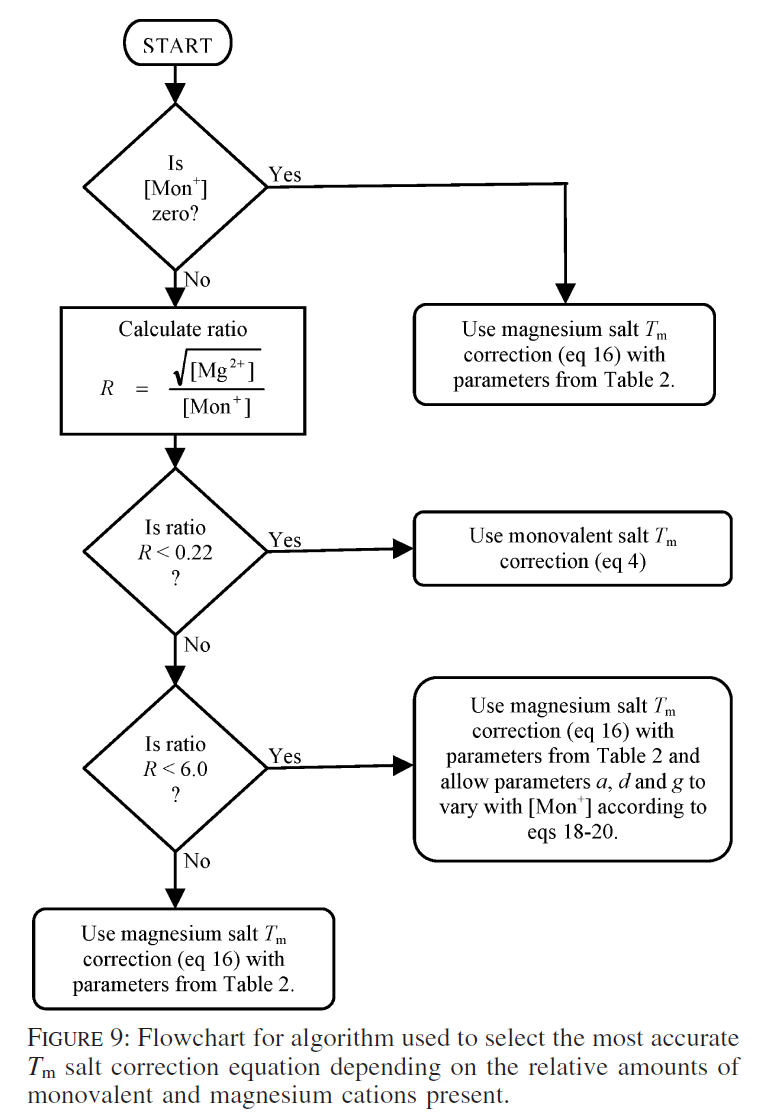

where the equations mentioned (Eq.4 and Eq.16) are the ones we gave in the EDA notebook.\
The complete function implementing this tree is given below (Thanks Claude!).\
We will use their complex function to compare performance with our developed models. 

**Things to keep in mind regarding the training and testing datasets**
1. Data in Table 4 was similarly used to train and develop their "model", so it is a fair comparison to use it here as well.
2. We do not compare the whole dataset in Table S2 since some of the data was obtained at different DNA concentrations, check EDA notebook for details. To this end, we have to evaluate their "model" again on this subset of the dataset of Table S2.

In [147]:
import math

def predict_tm_magnesium(tm_1M_Na, Nbp, fGC, Mg_total, Mon_total, dNTP_total=0.0):
    """
    Predict melting temperature (Tm) in buffers containing Mg2+ and monovalent ions.
    
    Based on Owczarzy et al. (2008) Biochemistry 47, 5336-5353.
    Algorithm from Figure 9.

    Parameters
    ----------
    tm_1M_Na   : float  – reference Tm in 1 M Na+ buffer (Celsius)
    Nbp        : int    – number of base pairs
    fGC        : float  – fraction of G·C base pairs (0 to 1)
    Mg_total   : float  – total [Mg2+] in mol/L
    Mon_total  : float  – total monovalent ion concentration [Mon+] in mol/L
                          (sum of [K+] + [Na+] + [Tris+], where [Tris+] ≈ half of [Tris])
    dNTP_total : float  – total dNTP concentration in mol/L (default 0)
                          Free [Mg2+] = Mg_total - dNTP_total (if positive)

    Returns
    -------
    float : predicted Tm in Celsius
    """

    # --- Parameters from Table 2 (constant values) ---
    a0 = 3.92e-5
    b  = -9.11e-6
    c  = 6.26e-5
    d0 = 1.42e-5
    e  = -4.82e-4
    f  = 5.25e-4
    g0 = 8.31e-5

    # Reference Tm in Kelvin
    tm_ref_K = tm_1M_Na + 273.15

    # Compute free [Mg2+] accounting for dNTP chelation
    if dNTP_total > 0:
        free_Mg = Mg_total - dNTP_total
        if free_Mg < 0:
            # Use association constant approach (Ka ~ 3e4 L/mol) when dNTP >= Mg
            Ka = 3e4
            # Solve quadratic: Ka*[Mg]^2 + (Ka*(dNTP-Mg_total)+1)*[Mg] - Mg_total = 0
            A_coef = Ka
            B_coef = Ka * (dNTP_total - Mg_total) + 1
            C_coef = -Mg_total
            discriminant = B_coef**2 - 4 * A_coef * C_coef
            free_Mg = (-B_coef + math.sqrt(discriminant)) / (2 * A_coef)
    else:
        free_Mg = Mg_total

    # --- Figure 9 algorithm: select correction based on R ---

    # Branch 1: no monovalent ions present → use Eq. 16 with Table 2 params
    if Mon_total == 0:
        inv_tm = _eq16(tm_ref_K, free_Mg, fGC, Nbp, a0, b, c, d0, e, f, g0)
        return _inv_to_celsius(inv_tm)

    R = math.sqrt(free_Mg) / Mon_total  # units: M^(-1/2)

    # Branch 2: R < 0.22 → monovalent ions dominant, use Eq. 4
    if R < 0.22:
        inv_tm = _eq4(tm_ref_K, Mon_total, fGC)
        return _inv_to_celsius(inv_tm)

    # Branch 3: 0.22 <= R < 6.0 → mixed regime, Eq. 16 with a, d, g varying (Eqs. 18-20)
    elif R < 6.0:
        a = a0 * (0.843 - 0.352 * math.sqrt(Mon_total) * math.log(Mon_total))
        d = d0 * (1.279 - 4.03e-3 * math.log(Mon_total)
                        - 8.03e-3 * (math.log(Mon_total))**2)
        g = g0 * (0.486 - 0.258 * math.log(Mon_total)
                        + 5.25e-3 * (math.log(Mon_total))**3)
        inv_tm = _eq16(tm_ref_K, free_Mg, fGC, Nbp, a, b, c, d, e, f, g)
        return _inv_to_celsius(inv_tm)

    # Branch 4: R >= 6.0 → Mg2+ dominant, Eq. 16 with constant Table 2 params
    else:
        inv_tm = _eq16(tm_ref_K, free_Mg, fGC, Nbp, a0, b, c, d0, e, f, g0)
        return _inv_to_celsius(inv_tm)


def _eq16(tm_ref_K, Mg, fGC, Nbp, a, b, c, d, e, f, g):
    """Equation 16: Tm magnesium correction (returns 1/Tm in K^-1)."""
    ln_Mg = math.log(Mg)
    inv_tm = (1.0 / tm_ref_K
              + a
              + b * ln_Mg
              + fGC * (c + d * ln_Mg)
              + (1.0 / (2 * (Nbp - 1))) * (e + f * ln_Mg + g * ln_Mg**2))
    return inv_tm


def _eq4(tm_ref_K, Mon, fGC):
    """Equation 4: monovalent ion Tm correction (returns 1/Tm in K^-1)."""
    ln_Mon = math.log(Mon)
    inv_tm = (1.0 / tm_ref_K
              + (4.29 * fGC - 3.95) * 1e-5 * ln_Mon
              + 9.40e-6 * ln_Mon**2)
    return inv_tm


def _inv_to_celsius(inv_tm_K):
    """Convert 1/Tm (K^-1) to Tm in Celsius."""
    return (1.0 / inv_tm_K) - 273.15


# # --- Example from the paper (page 5348) ---
# if __name__ == "__main__":
#     # 20-bp duplex, fGC = 0.6, 1.5 mM Mg2+, 10 mM Tris-HCl
#     # [Tris+] ≈ 5 mM (half of 10 mM Tris is protonated at pH 8.3)
#     tm_ref   = 76.3          # Tm in 1 M Na+ (°C)
#     Nbp      = 20
#     fGC      = 0.600
#     Mg       = 0.0015        # 1.5 mM
#     Mon      = 0.005         # ~5 mM Tris+
#     dNTP     = 0.0

#     result = predict_tm_magnesium(tm_ref, Nbp, fGC, Mg, Mon, dNTP)
#     print(f"Predicted Tm: {result:.1f} °C  (paper reports 67.9 °C, measured 68.5 °C)")




## 
# Tm_C at monovalent_mM = 1005 mM and Mg2+_mM = 0 mM is used as the reference Tm in 1 M Na+ for all sequences since it is the closest condition to 1 M Na+ in our dataset and it is the only condition in our dataset that has zero Mg2+ concentration, which is required for the reference Tm in 1 M Na+ according to the algorithm from Owczarzy et al. (2008) Biochemistry 47, 5336-5353.
# Copied directly from the paper Table 4 (not part of the training data)
# reference_tm ={'TTCTACCTATGTGAT': np.float64(53.2),
#  'GCAGTGGATGTGAGA': np.float64(62.4),
#  'CAGCCTCGTCGCAGC': np.float64(70.6),
#  'TGATTCTACCTATGTGATTT': np.float64(63.2),
#  'AGCTGCAGTGGATGTGAGAA': np.float64(72.3),
#  'CAGCCTCGTTCGCACAGCCC': np.float64(78.4),
#  'GTTCTATACTCTTGAAGTTGATTAC': np.float64(68.0),
#  'CTGGTCTGGATCTGAGAACTTCAGG': np.float64(75.8),
#  'CAGTGGGCTCCTGGGCGTGCTGGTC': np.float64(83.4),
#  'CTTAAGATATGAGAACTTCAACTAATGTGT': np.float64(72.4),
#  'AGTCTGGTCTGGATCTGAGAACTTCAGGCT': np.float64(80.1),
#  'GACCTGACGTGGACCGCTCCTGGGCGTGGT': np.float64(86.7)}
# This gives MAE=0.6C.

# Tm_C at monovalent_mM = 1.02 M is used as the reference Tm in 1 M Na+ for all sequences since it looks like that is what they did in the analysis shown in table 5 according to the main text of Owc-2008.
# Copied directly from the paper Table 2 of Owc-2004 (not part of the training data)
# reference_tm ={'TTCTACCTATGTGAT': np.float64(53.7),
#  'GCAGTGGATGTGAGA': np.float64(62.3),
#  'CAGCCTCGTCGCAGC': np.float64(72.0),
#  'TGATTCTACCTATGTGATTT': np.float64(64.4),
#  'AGCTGCAGTGGATGTGAGAA': np.float64(73.1),
#  'CAGCCTCGTTCGCACAGCCC': np.float64(78.1),
#  'GTTCTATACTCTTGAAGTTGATTAC': np.float64(67.7),
#  'CTGGTCTGGATCTGAGAACTTCAGG': np.float64(75.6),
#  'CAGTGGGCTCCTGGGCGTGCTGGTC': np.float64(83.4),
#  'CTTAAGATATGAGAACTTCAACTAATGTGT': np.float64(71.8),
#  'AGTCTGGTCTGGATCTGAGAACTTCAGGCT': np.float64(80.6),
#  'GACCTGACGTGGACCGCTCCTGGGCGTGGT': np.float64(86.4)}
# # This given MAE=0.8C as they report in table 5 of Owc-2008.

# # Evaluate the magnesium correction model on the training data using the reference Tm values for each sequence and the corresponding salt conditions, and calculate the MAE of the predictions compared to the actual Tm values in the training data
# magnesium_correction_predictions = []
# for idx, row in owc2008_table4.iterrows():
#     seq = row['sequence_5to3']
#     tm_ref = reference_tm.get(seq, None)
#     if tm_ref is not None:
#         Nbp = len(seq)
#         fGC = (seq.count('G') + seq.count('C')) / Nbp if Nbp > 0 else 0
#         Mg_total = row['Mg2+_mM'] * 1e-3  # convert mM to M
#         Mon_total = row['monovalent_mM'] * 1e-3  # convert mM to M
#         dNTP_total = 0.0  # Assuming no dNTPs in the training data

#         predicted_tm = predict_tm_magnesium(tm_ref, Nbp, fGC, Mg_total, Mon_total, dNTP_total)
#         magnesium_correction_predictions.append(predicted_tm)
#     else:
#         magnesium_correction_predictions.append(None)  # or some default value if reference Tm is not available

# # Calculate MAE for the magnesium correction model predictions compared to actual Tm values in the training data (only for rows where we have a valid prediction)
# valid_predictions = [(pred, actual) for pred, actual in zip(magnesium_correction_predictions, owc2008_table4['Tm_C']) if pred is not None]
# if valid_predictions:
#     preds, actuals = zip(*valid_predictions)
#     mae_magnesium_correction = mean_absolute_error(actuals, preds)
#     print(f"MAE of Magnesium Correction Model on Training Data: {mae_magnesium_correction:.4f} °C")

## Testing on the data from Table 4 (Full training data)

In [149]:
training_predictions_loco_gc = our_model_loco_gc.predict(owc2008_table4[our_feature_set])
training_mae_loco_gc = mean_absolute_error(owc2008_table4['Tm_C'], training_predictions_loco_gc)

training_predictions_loco_length = our_model_loco_length.predict(owc2008_table4[our_feature_set])
training_mae_loco_length = mean_absolute_error(owc2008_table4['Tm_C'], training_predictions_loco_length)

training_predictions_loso = our_model_loso.predict(owc2008_table4[our_feature_set])
training_mae_loso = mean_absolute_error(owc2008_table4['Tm_C'], training_predictions_loso)

training_predictions_full = our_model_full.predict(owc2008_table4[our_feature_set])
training_mae_full = mean_absolute_error(owc2008_table4['Tm_C'], training_predictions_full)

In [150]:
# Evaluate the model of the paper again on the training data using the reference Tm values for each sequence and the corresponding salt conditions
# Calculate the MAE of the predictions compared to the actual Tm values in the training data

# Tm_C at monovalent_mM = 1005 mM and Mg2+_mM = 0 mM is used as the reference Tm in 1 M Na+ for all sequences since it is the closest condition to 1 M Na+ in our dataset and it is the only condition in our dataset that has zero Mg2+ concentration, which is required for the reference Tm in 1 M Na+ according to the algorithm from Owczarzy et al. (2008) Biochemistry 47, 5336-5353.
# Copied directly from the paper Table 4 (not part of the training data)
reference_tm ={'TTCTACCTATGTGAT': np.float64(53.2),
 'GCAGTGGATGTGAGA': np.float64(62.4),
 'CAGCCTCGTCGCAGC': np.float64(70.6),
 'TGATTCTACCTATGTGATTT': np.float64(63.2),
 'AGCTGCAGTGGATGTGAGAA': np.float64(72.3),
 'CAGCCTCGTTCGCACAGCCC': np.float64(78.4),
 'GTTCTATACTCTTGAAGTTGATTAC': np.float64(68.0),
 'CTGGTCTGGATCTGAGAACTTCAGG': np.float64(75.8),
 'CAGTGGGCTCCTGGGCGTGCTGGTC': np.float64(83.4),
 'CTTAAGATATGAGAACTTCAACTAATGTGT': np.float64(72.4),
 'AGTCTGGTCTGGATCTGAGAACTTCAGGCT': np.float64(80.1),
 'GACCTGACGTGGACCGCTCCTGGGCGTGGT': np.float64(86.7)}

magnesium_correction_predictions_training = []

for idx, row in owc2008_table4.iterrows():
    seq = row['sequence_5to3']
    # Use Tm from the condition with 1.02 M monovalent ions as the reference Tm in 1 M Na+.

    tm_ref = reference_tm.get(seq, None)

    if tm_ref is not None:
        Nbp = len(seq)
        fGC = (seq.count('G') + seq.count('C')) / Nbp if Nbp > 0 else 0
        Mg_total = row['Mg2+_mM'] * 1e-3  # convert mM to M
        Mon_total = row['monovalent_mM'] * 1e-3  # convert mM to M
        dNTP_total = 0.0  # Assuming no dNTPs in the test data

        predicted_tm = predict_tm_magnesium(tm_ref, Nbp, fGC, Mg_total, Mon_total, dNTP_total)
        magnesium_correction_predictions_training.append(predicted_tm)
    else:
        magnesium_correction_predictions_training.append(None)  # or some default value if reference Tm is not available

# Calculate MAE for the magnesium correction model predictions compared to actual Tm values in the training data (only for rows where we have a valid prediction)
valid_predictions_training = [(pred, actual) for pred, actual in zip(magnesium_correction_predictions_training, owc2008_table4['Tm_C']) if pred is not None]
if valid_predictions_training:
    preds_training, actuals_training = zip(*valid_predictions_training)
    mae_magnesium_correction_training = mean_absolute_error(actuals_training, preds_training)

In [151]:
# Show the results in a table for easy comparison
print("Comparison of MAE of our chosen models on the full training data compared to the magnesium correction model:")
pd.DataFrame({
    'MAE on Training Data (°C)': [training_mae_loso, training_mae_loco_gc, training_mae_loco_length,training_mae_full, mae_magnesium_correction_training]
}, index=['Our Model (LOSO)', 'Our Model (LOCO GC)', 'Our Model (LOCO Length)', 'Our Model (Full GAM)', 'Owc-2008 Correction Model']).T

Comparison of MAE of our chosen models on the full training data compared to the magnesium correction model:


,Our Model (LOSO),Our Model (LOCO GC),Our Model (LOCO Length),Our Model (Full GAM),Owc-2008 Correction Model
MAE on Training Data (°C),1.335808,1.444493,1.548351,1.334051,0.582914


## Testing on the data from Table S2

In [152]:
# Showing a sample of the data with the features used in our chosen models for reference
owc2008_tableS2[['sequence_5to3']+our_feature_set].sample(5)

,sequence_5to3,monovalent_mM,Mg2+_mM,length_bp,GC_content,monovalent_mM-length_bp,monovalent_mM-GC_content,Mg2+_mM-length_bp,Mg2+_mM-GC_content
10,TCTCAATGGTGTCACG,55.0,3.0,16,0.50,880.0,27.50,48.0,1.50
19,ATCTCCGAAATACAGAACTA,55.0,125.0,20,0.35,1100.0,19.25,2500.0,43.75
1,CTGACGACAAGACT,5.0,10.0,14,0.50,70.0,2.50,140.0,5.00
20,ATCTCCGAAATACAGAACTA,105.0,20.0,20,0.35,2100.0,36.75,400.0,7.00
27,GCAATAGAAAGAGGAAATAATAGTTTTATATTCGACCTAG,55.0,1.5,40,0.30,2200.0,16.50,60.0,0.45


### Testing on the entire test set

In [154]:
# Testing our models on the full test data (39 data points)
test_predictions_loso = our_model_loso.predict(owc2008_tableS2[our_feature_set])
test_mae_loso = mean_absolute_error(owc2008_tableS2['Tm_C'], test_predictions_loso)

test_predictions_loco_gc = our_model_loco_gc.predict(owc2008_tableS2[our_feature_set])
test_mae_loco_gc = mean_absolute_error(owc2008_tableS2['Tm_C'], test_predictions_loco_gc)

test_predictions_loco_length = our_model_loco_length.predict(owc2008_tableS2[our_feature_set])
test_mae_loco_length = mean_absolute_error(owc2008_tableS2['Tm_C'], test_predictions_loco_length)

test_predictions_full = our_model_full.predict(owc2008_tableS2[our_feature_set])
test_mae_full = mean_absolute_error(owc2008_tableS2['Tm_C'], test_predictions_full)

In [155]:
# Evaluate the model of the paper again on the test data using the reference Tm values for each sequence and the corresponding salt conditions
# And calculate the MAE of the predictions compared to the actual Tm values in the test data
magnesium_correction_predictions_test = []
for idx, row in owc2008_tableS2.iterrows():
    seq = row['sequence_5to3']
    # Use column Tm1_C as the referece Tm in 1M Na+.
    tm_ref = row['Tm1_C']
    if tm_ref is not None:
        Nbp = len(seq)
        fGC = (seq.count('G') + seq.count('C')) / Nbp if Nbp > 0 else 0
        Mg_total = row['Mg2+_mM'] * 1e-3  # convert mM to M
        Mon_total = row['monovalent_mM'] * 1e-3  # convert mM to M
        dNTP_total = 0.0  # Assuming no dNTPs in the test data

        predicted_tm = predict_tm_magnesium(tm_ref, Nbp, fGC, Mg_total, Mon_total, dNTP_total)
        magnesium_correction_predictions_test.append(predicted_tm)
    else:
        magnesium_correction_predictions_test.append(None)  # or some default value if reference Tm is not available

# Calculate MAE for the magnesium correction model predictions compared to actual Tm values in the test data (only for rows where we have a valid prediction)
valid_predictions_test = [(pred, actual) for pred, actual in zip(magnesium_correction_predictions_test, owc2008_tableS2['Tm_C']) if pred is not None]
if valid_predictions_test:
    preds_test, actuals_test = zip(*valid_predictions_test)
    mae_magnesium_correction_test = mean_absolute_error(actuals_test, preds_test)

In [156]:
# Show the results in a table for easy comparison
print("Comparison of MAE of our chosen models on the full test data compared to the magnesium correction model:")
pd.DataFrame({
    'MAE on full Test Data (°C)': [test_mae_loso, test_mae_loco_gc, test_mae_loco_length, test_mae_full, mae_magnesium_correction_test]
}, index=['Our Model (LOSO)', 'Our Model (LOCO GC)', 'Our Model (LOCO Length)', 'Our Model (Full GAM)', 'Owc-2008 Correction Model']).T

Comparison of MAE of our chosen models on the full test data compared to the magnesium correction model:


,Our Model (LOSO),Our Model (LOCO GC),Our Model (LOCO Length),Our Model (Full GAM),Owc-2008 Correction Model
MAE on full Test Data (°C),6.428158,6.919956,1.523195,6.591311,0.614954


### Testing on sequences which have lengths similar to the training data (10-30 bp)

In [157]:
# Remove any sequences from Table S2 that have length < 15 bp or > 30 bp to match the length range of our training data
owc2008_tableS2_filtered = owc2008_tableS2[(owc2008_tableS2['length_bp'] >= 15) & (owc2008_tableS2['length_bp'] <= 30)]
print(f"Number of used sequences from Table S2 (Original: {len(owc2008_tableS2)}) after filtering by length: {len(owc2008_tableS2_filtered)}")

Number of used sequences from Table S2 (Original: 39) after filtering by length: 20


In [158]:
# Testing our model on the filtered test data
test_predictions_loco_gc_filtered = our_model_loco_gc.predict(owc2008_tableS2_filtered[our_feature_set])
test_mae_loco_gc_filtered = mean_absolute_error(owc2008_tableS2_filtered['Tm_C'], test_predictions_loco_gc_filtered)

test_predictions_loco_length_filtered = our_model_loco_length.predict(owc2008_tableS2_filtered[our_feature_set])
test_mae_loco_length_filtered = mean_absolute_error(owc2008_tableS2_filtered['Tm_C'], test_predictions_loco_length_filtered)

test_predictions_loso_filtered = our_model_loso.predict(owc2008_tableS2_filtered[our_feature_set])
test_mae_loso_filtered = mean_absolute_error(owc2008_tableS2_filtered['Tm_C'], test_predictions_loso_filtered)

test_predictions_full = our_model_full.predict(owc2008_tableS2_filtered[our_feature_set])
test_mae_full = mean_absolute_error(owc2008_tableS2_filtered['Tm_C'], test_predictions_full)

In [159]:
# Evaluate the model of the paper again on the test data using the reference Tm values for each sequence and the corresponding salt conditions, and calculate the MAE of the predictions compared to the actual Tm values in the test data
magnesium_correction_predictions_test = []
for idx, row in owc2008_tableS2_filtered.iterrows():
    seq = row['sequence_5to3']
    # Use column Tm1_C as the referece Tm in 1M Na+.
    tm_ref = row['Tm1_C']
    if tm_ref is not None:
        Nbp = len(seq)
        fGC = (seq.count('G') + seq.count('C')) / Nbp if Nbp > 0 else 0
        Mg_total = row['Mg2+_mM'] * 1e-3  # convert mM to M
        Mon_total = row['monovalent_mM'] * 1e-3  # convert mM to M
        dNTP_total = 0.0  # Assuming no dNTPs in the test data

        predicted_tm = predict_tm_magnesium(tm_ref, Nbp, fGC, Mg_total, Mon_total, dNTP_total)
        magnesium_correction_predictions_test.append(predicted_tm)
    else:
        magnesium_correction_predictions_test.append(None)  # or some default value if reference Tm is not available

# Calculate MAE for the magnesium correction model predictions compared to actual Tm values in the test data (only for rows where we have a valid prediction)
valid_predictions_test = [(pred, actual) for pred, actual in zip(magnesium_correction_predictions_test, owc2008_tableS2_filtered['Tm_C']) if pred is not None]
if valid_predictions_test:
    preds_test, actuals_test = zip(*valid_predictions_test)
    mae_magnesium_correction_test = mean_absolute_error(actuals_test, preds_test)

In [161]:
# Show the results in a table for easy comparison
print("Comparison of MAE of our chosen models on the filtered test data compared to the magnesium correction model:")
pd.DataFrame({
    'MAE on filtered Test Data (°C)': [test_mae_loso_filtered, test_mae_loco_gc_filtered, test_mae_loco_length_filtered, test_mae_full, mae_magnesium_correction_test]
}, index=['Our Model (LOSO)', 'Our Model (LOCO GC)', 'Our Model (LOCO Length)', 'Our Model (Full GAM)','Owc-2008 Correction Model']).T

Comparison of MAE of our chosen models on the filtered test data compared to the magnesium correction model:


,Our Model (LOSO),Our Model (LOCO GC),Our Model (LOCO Length),Our Model (Full GAM),Owc-2008 Correction Model
MAE on filtered Test Data (°C),1.331753,1.332947,1.185532,1.334037,0.378032


# Conclusion

It is indeed interesting how the LeaveOneLengthOut is performing the best compared to the other models we trained, even though the CV results were not so obvious.\
One could expect a Voter model that averages the different folds to perform better than the best fold result (the crowd effect), but this will lead to a complex and less interpretable model, so we stick with the model with the best validation MAE.\
Compared to the models of Owc-2008, we are not quite there, BUT we are using a SINGLE model instead of a tree of models. Also, our model is performing similar (and sometimes better) compared to other models developed for this purpose (Table 5 of Owc-2008) with the extra advantage of covering all salt types and ranges in one single formula!\ 
The other important aspects of the good performance of our model are how 1) it captures the minimal set of features quite nicely in agreement with literature and 2) it being trained on ONLY about 400 data points, which is less than half what Owc-2008 used to develop their models (>1000 in total).

Future directions could include:
1.	Using more data: That will need to be done carefully since we saw how having more data (LOSO and Full GAM) can overfit with the addition of just less than 50 more data points, so one will need to first explore what types of additional data to include without overfitting or hugely increase the data set. One suggestion is having more length-distributed data points rather than multiple sequences of the same length done over multiple salt conditions.
2.	Reexploring the modern set of features: It seems to require more data, but if it has the potential of giving us a LinearRegression model that outperforms the standard non-linear ones then it is worth investigating it further.
3.	Further investigation of splits of the dataset at hand and the best performing model: It is quite surprising how this model is doing that good with such limited number of data points, so it is important to explore the fitted model smooth functions and what aspects of the additional data lead to overfitting in the other models. Due to the time limitation, I could not explore this.


# References:
1. SantaLucia-1998: J. SantaLucia, A unified view of polymer, dumbbell, and oligonucleotide DNA nearest-neighbor thermodynamics, Proc. Natl. Acad. Sci. U.S.A. 95 (4) 1460-1465, https://doi.org/10.1073/pnas.95.4.1460 (1998).
2. Owc-2004: Effects of Sodium Ions on DNA Duplex Oligomers:  Improved Predictions of Melting Temperatures
Richard Owczarzy, Yong You, Bernardo G. Moreira, Jeffrey A. Manthey, Lingyan Huang, Mark A. Behlke, and Joseph A. Walder
Biochemistry 2004 43 (12), 3537-3554
DOI: https://doi.org/10.1021/bi034621r
3. Owc-2008: Predicting Stability of DNA Duplexes in Solutions Containing Magnesium and Monovalent Cations
Richard Owczarzy, Bernardo G. Moreira, Yong You, Mark A. Behlke, and Joseph A. Walder
Biochemistry 2008 47 (19), 5336-5353
DOI: https://doi.org/10.1021/bi702363u
4. Unz-2010: J.M. Huguet, C.V. Bizarro, N. Forns, S.B. Smith, C. Bustamante, & F. Ritort, Single-molecule derivation of salt dependent base-pair free energies in DNA, Proc. Natl. Acad. Sci. U.S.A. 107 (35) 15431-15436, https://doi.org/10.1073/pnas.1001454107 (2010).
5. Unz-2017: Josep Maria Huguet, Marco Ribezzi-Crivellari, Cristiano Valim Bizarro, Felix Ritort, Derivation of nearest-neighbor DNA parameters in magnesium from single molecule experiments, Nucleic Acids Research, Volume 45, Issue 22, 15 December 2017, Pages 12921–12931, https://doi.org/10.1093/nar/gkx1161
6. Volo-2018: Alexander Vologodskii, Maxim D. Frank-Kamenetskii, DNA melting and energetics of the double helix, Physics of Life Reviews, Volume 25, 2018, Pages 1-21, ISSN 1571-0645, https://doi.org/10.1016/j.plrev.2017.11.012.

